In [1]:
import os
import glob
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch
import seaborn as sns


In [2]:



# Check if CUDA (GPU) is available
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: Using CPU for training. This will be slow.")

Is CUDA available? True
Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:

# Point directly to your training labels directory using raw string for Windows paths
LABELS_DIR = r'D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\train\labels'

# RDD2022 Class Mapping
CLASS_MAP = {
    0: 'D00_Longitudinal_Crack',
    1: 'D10_Transverse_Crack',
    2: 'D20_Alligator_Crack',
    3: 'D40_Pothole'
}

data = []
txt_files = glob.glob(os.path.join(LABELS_DIR, '*.txt'))

print(f"Found {len(txt_files)} label files. Parsing annotations...")

for file_path in txt_files:
    filename = os.path.basename(file_path)
    # Extract country from filename prefix (e.g., "Japan_0001.txt" -> "Japan")
    country = filename.split('_')[0] if '_' in filename else 'Unknown'
    
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            class_id = int(parts[0])
            # YOLO format: class_id, x_center, y_center, width, height (normalized 0-1)
            width = float(parts[3])
            height = float(parts[4])
            
            if class_id in CLASS_MAP:
                data.append({
                    'country': country,
                    'class_id': class_id,
                    'class_name': CLASS_MAP[class_id],
                    'area': width * height,
                    'aspect_ratio': width / height if height > 0 else 0
                })

df = pd.DataFrame(data)

if df.empty:
    print("WARNING: DataFrame is empty. Please verify that your LABELS_DIR path is correct and contains .txt files.")
else:
    print(f"Successfully extracted {len(df):,} total bounding box annotations!\n")
    print("Class Distribution:")
    print(df['class_name'].value_counts())
    print("=" * 60)

    # ---------------------------------------------------------
    # 1. Chi-Square Test of Independence (Country vs. Damage Type)
    # ---------------------------------------------------------
    contingency_table = pd.crosstab(df['country'], df['class_name'])
    chi2, p_chi, dof, _ = stats.chi2_contingency(contingency_table)
    print("1. CHI-SQUARE TEST (Country vs. Damage Type)")
    print(f"   Chi-Square Statistic: {chi2:.4f}")
    print(f"   P-value: {p_chi:.4e}")
    print("   Result:", "Significant dependency found." if p_chi < 0.05 else "Independent distribution.")
    print("-" * 60)

    # ---------------------------------------------------------
    # 2. One-Way ANOVA (Damage Type vs. Bounding Box Area)
    # ---------------------------------------------------------
    groups = [df[df['class_id'] == cid]['area'].values for cid in CLASS_MAP.keys()]
    f_stat, p_anova = stats.f_oneway(*groups)
    print("2. ONE-WAY ANOVA (Damage Type vs. Bounding Box Area)")
    print(f"   F-Statistic: {f_stat:.4f}")
    print(f"   P-value: {p_anova:.4e}")
    print("   Result:", "Significant difference in size across damage types." if p_anova < 0.05 else "No significant size difference.")
    print("-" * 60)

    # ---------------------------------------------------------
    # 3. Two-Sample Independent t-test (D00 vs. D10 Aspect Ratio)
    # ---------------------------------------------------------
    d00_aspect = df[df['class_id'] == 0]['aspect_ratio']
    d10_aspect = df[df['class_id'] == 1]['aspect_ratio']
    t_stat, p_t = stats.ttest_ind(d00_aspect, d10_aspect, equal_var=False)
    print("3. INDEPENDENT T-TEST (D00 Longitudinal vs. D10 Transverse Aspect Ratio)")
    print(f"   T-Statistic: {t_stat:.4f}")
    print(f"   P-value: {p_t:.4e}")
    print("   Result:", "Significant shape difference between crack types." if p_t < 0.05 else "No significant shape difference.")
    print("=" * 60)

Found 26869 label files. Parsing annotations...
Successfully extracted 41,668 total bounding box annotations!

Class Distribution:
class_name
D00_Longitudinal_Crack    18201
D10_Transverse_Crack       8386
D40_Pothole                7554
D20_Alligator_Crack        7527
Name: count, dtype: int64
1. CHI-SQUARE TEST (Country vs. Damage Type)
   Chi-Square Statistic: 16464.5327
   P-value: 0.0000e+00
   Result: Significant dependency found.
------------------------------------------------------------
2. ONE-WAY ANOVA (Damage Type vs. Bounding Box Area)
   F-Statistic: 3578.5112
   P-value: 0.0000e+00
   Result: Significant difference in size across damage types.
------------------------------------------------------------
3. INDEPENDENT T-TEST (D00 Longitudinal vs. D10 Transverse Aspect Ratio)
   T-Statistic: -149.6298
   P-value: 0.0000e+00
   Result: Significant shape difference between crack types.


C:\Users\ssriv\AppData\Local\Temp\ipykernel_34256\3630971740.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ssriv\AppData\Local\Temp\ipykernel_34256\3630971740.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


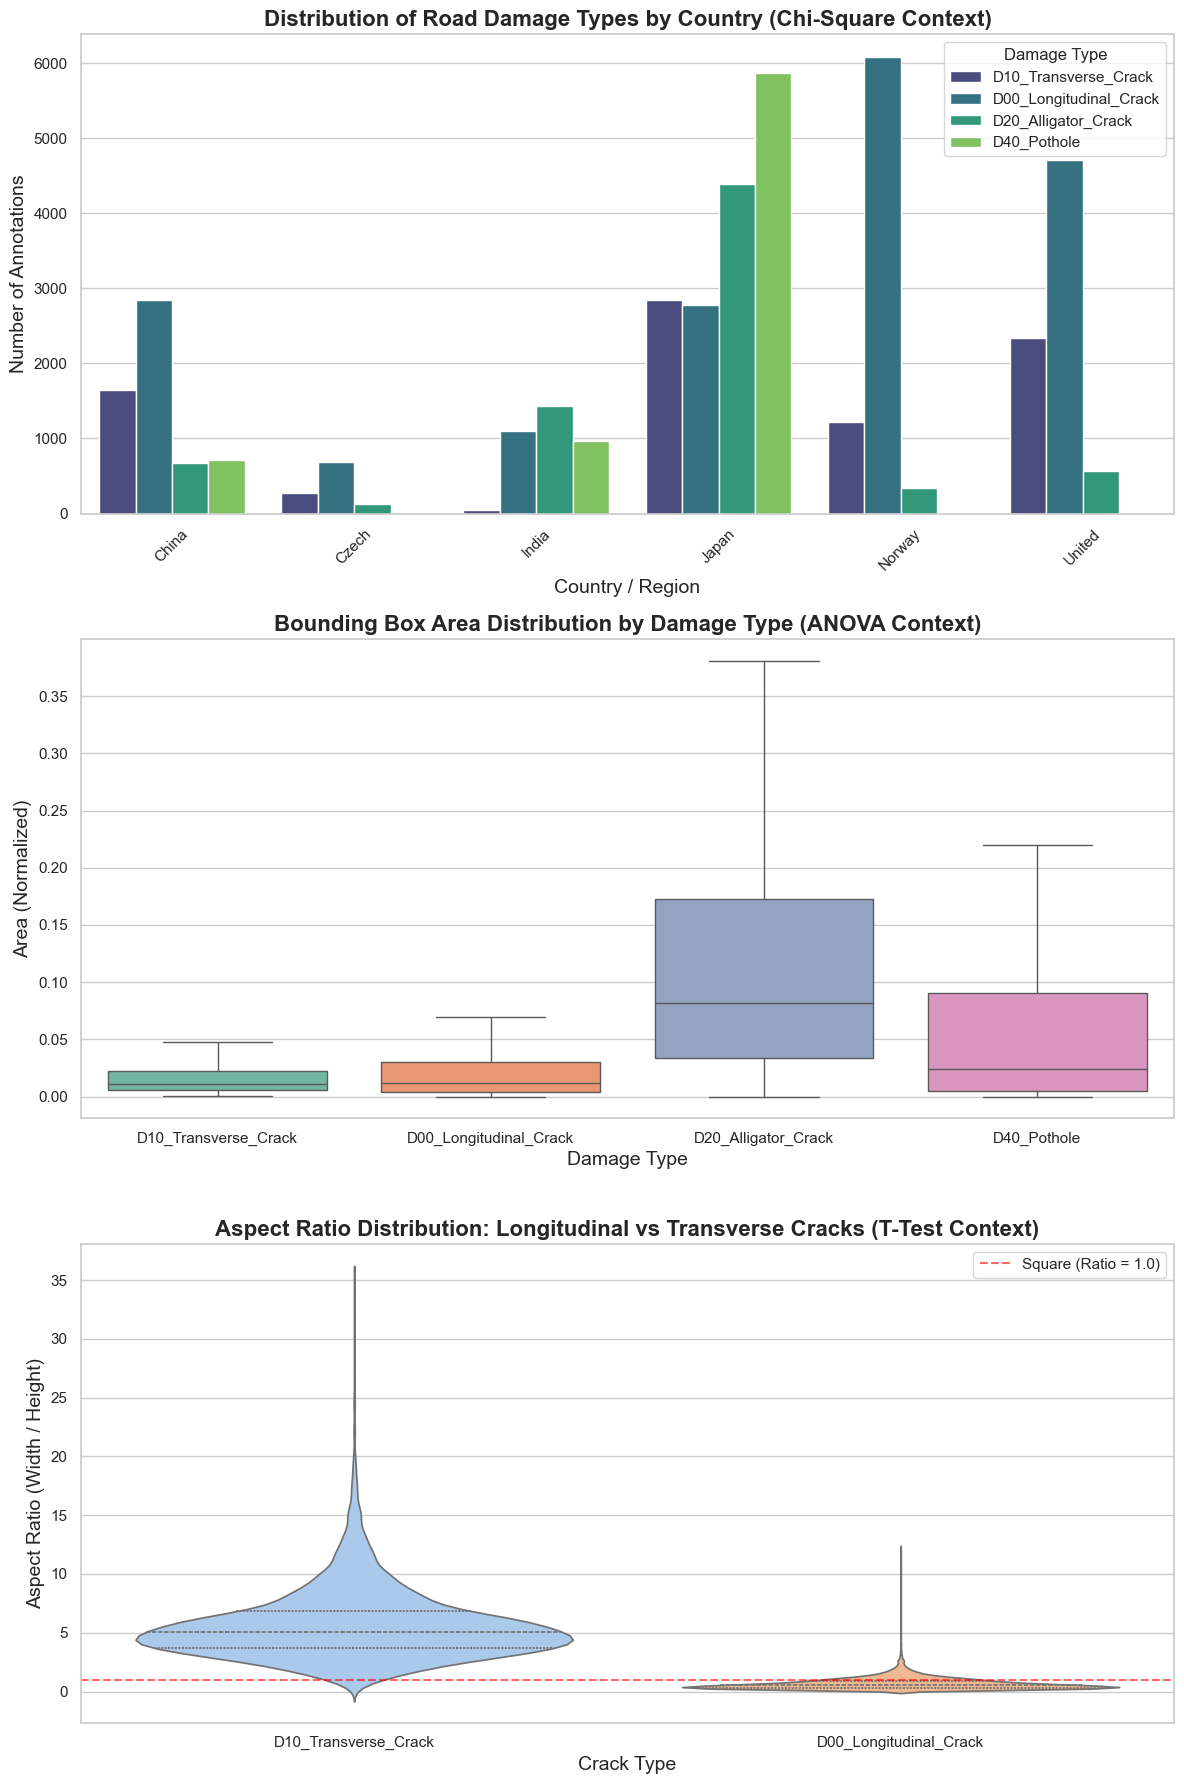

In [4]:


# Set the visual style for academic/professional plotting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

# Create a figure with 3 subplots (stacked vertically)
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# ==========================================
# 1. Chi-Square Visualization: Damage Type per Country
# ==========================================
# A grouped countplot shows the distribution of classes across regions
sns.countplot(
    data=df, 
    x='country', 
    hue='class_name', 
    ax=axes[0], 
    palette="viridis"
)
axes[0].set_title('Distribution of Road Damage Types by Country (Chi-Square Context)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Country / Region', fontsize=14)
axes[0].set_ylabel('Number of Annotations', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Damage Type', loc='upper right')

# ==========================================
# 2. ANOVA Visualization: Bounding Box Area
# ==========================================
# A boxplot shows the size distribution. We use a log scale on the Y-axis 
# because bounding box areas usually have massive outliers (tiny cracks vs huge potholes).
sns.boxplot(
    data=df, 
    x='class_name', 
    y='area', 
    ax=axes[1], 
    palette="Set2",
    showfliers=False # Hiding extreme outliers for cleaner visualization
)
axes[1].set_title('Bounding Box Area Distribution by Damage Type (ANOVA Context)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Damage Type', fontsize=14)
axes[1].set_ylabel('Area (Normalized)', fontsize=14)

# ==========================================
# 3. T-Test Visualization: Aspect Ratio (D00 vs D10)
# ==========================================
# Filter the dataset for only Longitudinal (D00) and Transverse (D10) cracks
df_cracks = df[df['class_id'].isin([0, 1])]

# A violin plot perfectly shows the shape of the distribution of aspect ratios
sns.violinplot(
    data=df_cracks, 
    x='class_name', 
    y='aspect_ratio', 
    ax=axes[2], 
    palette="pastel",
    inner="quartile"
)
axes[2].set_title('Aspect Ratio Distribution: Longitudinal vs Transverse Cracks (T-Test Context)', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Crack Type', fontsize=14)
axes[2].set_ylabel('Aspect Ratio (Width / Height)', fontsize=14)

# Add a horizontal line at Aspect Ratio = 1.0 (perfect square) for reference
axes[2].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Square (Ratio = 1.0)')
axes[2].legend()

# Adjust layout to prevent overlapping text
plt.tight_layout()
plt.show()

In [5]:
import urllib.request
import os
from ultralytics import YOLO

weights_url = 'https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8s.pt'
weights_file = 'yolov8s.pt'

# 1. Check if we already have the file. If not, download it cleanly.
if not os.path.exists(weights_file):
    print("Downloading YOLOv8s weights directly...")
    urllib.request.urlretrieve(weights_url, weights_file)
    print("Download complete!")
else:
    print("Weights file already exists locally.")

# 2. Load the model directly from the local file
model = YOLO(weights_file) 

print("Model loaded successfully.")

Download complete!
Model loaded successfully.


In [9]:
results = model.train(
    data='road_damage.yaml',         
    epochs=20,                   
    imgsz=640,                   
    batch=16,                    
    name='rdd2022_balanced',      
    device=0,                    
    
    # --- REMOVED IMBALANCE FIXES ---
    # The image_weights and fl_gamma arguments were causing the crash.
    # -----------------------
    
    patience=5,                 
    save_period=3                
)

Ultralytics 8.4.152  Python-3.13.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=road_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rdd2022_balanced-3, nbs=64, nms=None,

In [10]:
# Validate the trained model
metrics = model.val()

print(f"Mean Average Precision (mAP50-95): {metrics.box.map}")
print(f"Mean Average Precision (mAP50): {metrics.box.map50}")

Ultralytics 8.4.152  Python-3.13.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1375.21202.9 MB/s, size: 383.8 KB)
val: Scanning D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\val\labels.cache... 5758 images, 1837 backgrounds, 544 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 2.2Git/s 0.0s
val: D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\val\images\China_Drone_000061.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 4. Possible class labels are 0-3
val: D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\val\images\China_Drone_000861.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 4. Possible class labels are 0-3
val: D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\val\images\China_Drone_001045.jpg: ignoring corrupt image/label: Label class 4 exceeds dat

In [14]:
import glob
import random
from IPython.display import Image, display

# Grab 3 random images from your test folder
test_images = glob.glob(r'D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\test\images\*.jpg')
sample_images = random.sample(test_images, 3)

# Load your best trained weights
# (The path is usually 'runs/detect/rdd2022_yolov8s/weights/best.pt')
# Locate the trained YOLO checkpoint
checkpoint_dir = os.path.join(
    "runs", "detect", "rdd2022_balanced", "weights"
)
best_weights = os.path.join(checkpoint_dir, "best.pt")

if not os.path.isfile(best_weights):
    matches = glob.glob(
        os.path.join("runs", "detect", "**", "best.pt"),
        recursive=True
    )
    if not matches:
        raise FileNotFoundError(
            "Could not find best.pt in the runs/detect directory."
        )
    best_weights = matches[0]

model = YOLO(best_weights)
print(f"Loaded weights: {best_weights}")

# Run inference and save the output
inference_results = model.predict(
    source=sample_images, 
    conf=0.25,                   # Confidence threshold (only show boxes with >25% confidence)
    save=True,                   # Save the images with drawn boxes
    project='runs/detect',
    name='test_inference'
)

print("Inference complete. Check the 'runs/detect/test_inference' folder for the images with bounding boxes.")

Loaded weights: runs\detect\rdd2022_balanced-3\weights\best.pt

0: 640x640 1 D00_Longitudinal_Crack, 5.3ms
1: 640x640 1 D00_Longitudinal_Crack, 5.3ms
2: 640x640 1 D00_Longitudinal_Crack, 5.3ms
Speed: 1.9ms preprocess, 5.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Sept-modules-assignments\AIDL\runs\detect\runs\detect\test_inference
Inference complete. Check the 'runs/detect/test_inference' folder for the images with bounding boxes.


# data balancing

In [20]:
import os
import shutil
import random
import glob

# ==========================================
# 1. Configuration & Paths
# ==========================================
# Your existing directories
images_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\train\images"
labels_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\train\labels"

# New directories to safely store the removed data
backup_images_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\train\backup_images"
backup_labels_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\train\backup_labels"

os.makedirs(backup_images_dir, exist_ok=True)
os.makedirs(backup_labels_dir, exist_ok=True)

# We want to bring the D00 count down to roughly match the others (~8,000)
TARGET_D00_COUNT = 8500 

# ==========================================
# 2. Analyze the Dataset
# ==========================================
txt_files = glob.glob(os.path.join(labels_dir, "*.txt"))

pure_d00_files = []
total_d00_annotations = 0

print(f"Scanning {len(txt_files)} label files...")

for txt_path in txt_files:
    with open(txt_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    classes_in_file = set()
    d00_in_file = 0
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) > 0:
            class_id = int(parts[0])
            classes_in_file.add(class_id)
            if class_id == 0:
                d00_in_file += 1
                
    total_d00_annotations += d00_in_file
    
    # If the file ONLY contains Class 0 (D00), it is safe to remove
    if len(classes_in_file) == 1 and 0 in classes_in_file:
        pure_d00_files.append((txt_path, d00_in_file))

annotations_to_remove = total_d00_annotations - TARGET_D00_COUNT

print(f"Initial D00 Annotations: {total_d00_annotations:,}")
print(f"Target D00 Annotations:  {TARGET_D00_COUNT:,}")
print(f"Targeting to remove:     {annotations_to_remove:,} annotations")

# ==========================================
# 3. Safely Move Files to Backup
# ==========================================
if annotations_to_remove > 0:
    # Shuffle the list to ensure random sampling across different countries/lighting
    random.seed(42) 
    random.shuffle(pure_d00_files)
    
    removed_annotations = 0
    files_moved = 0
    
    for txt_path, d00_count in pure_d00_files:
        if removed_annotations >= annotations_to_remove:
            break
            
        base_name = os.path.basename(txt_path)
        
        # 1. Move the Label
        shutil.move(txt_path, os.path.join(backup_labels_dir, base_name))
        
        # 2. Move the Image (Checking both .jpg and .png just in case)
        img_name_jpg = base_name.replace('.txt', '.jpg')
        img_path_jpg = os.path.join(images_dir, img_name_jpg)
        
        if os.path.exists(img_path_jpg):
            shutil.move(img_path_jpg, os.path.join(backup_images_dir, img_name_jpg))
            
        removed_annotations += d00_count
        files_moved += 1
        
    print("-" * 40)
    print("UNDERSAMPLING COMPLETE!")
    print(f"Successfully moved {files_moved:,} image/label pairs to the backup folders.")
    print(f"New estimated D00 count: {total_d00_annotations - removed_annotations:,}")
else:
    print("Dataset is already balanced or has fewer D00 annotations than the target.")

Scanning 22339 label files...
Initial D00 Annotations: 10,217
Target D00 Annotations:  8,500
Targeting to remove:     1,717 annotations
----------------------------------------
UNDERSAMPLING COMPLETE!
Successfully moved 232 image/label pairs to the backup folders.
New estimated D00 count: 9,784


In [21]:
from ultralytics import YOLO

# 1. Load the pre-trained weights again (starting fresh)
model_balanced = YOLO('yolov8s.pt') 

print("Starting training on the balanced dataset...")

# 2. Run the training loop
results_balanced = model_balanced.train(
    data='road_damage.yaml',         
    epochs=20,                   
    imgsz=640,                   
    batch=16,                    
    name='rdd2022_balanced_final', # New folder name for these weights
    device=0,                    
    patience=5,                 
    save_period=5                
)

print("Balanced training complete!")

Starting training on the balanced dataset...
Ultralytics 8.4.152  Python-3.13.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=road_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

In [22]:
# Validate the trained model
balanced_metrics = model_balanced.val()

print(f"Mean Average Precision (mAP50-95): {balanced_metrics.box.map}")
print(f"Mean Average Precision (mAP50): {balanced_metrics.box.map50}")

Ultralytics 8.4.152  Python-3.13.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1867.31783.0 MB/s, size: 385.6 KB)
val: Scanning D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\val\labels.cache... 5758 images, 2015 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 805.0Mit/s 0.0s
val: D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\val\images\Japan_006536.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 8.9it/s 40.5s0.1ss
                   all       5758       8775      0.629      0.564      0.595      0.325
D00_Longitudinal_Crack       2011       3890      0.621      0.418      0.468      0.246
  D10_Transverse_Crack       1158       1769      0.576      0.505      0.518       0.25
   D20_Alligator_Crack       1222 

In [23]:
import glob
import random
from IPython.display import Image, display

# Grab 5 random images from your test folder
test_images = glob.glob(r'D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\test\images\*.jpg')
sample_images = random.sample(test_images, 5)

# Load your best trained weights
# (The path is usually 'runs/detect/rdd2022_yolov8s/weights/best.pt')
# Locate the trained YOLO checkpoint
checkpoint_dir = os.path.join(
    "runs", "detect", "rdd2022_balanced_final-2", "weights"
)
best_weights = os.path.join(checkpoint_dir, "best.pt")

if not os.path.isfile(best_weights):
    matches = glob.glob(
        os.path.join("runs", "detect", "**", "best.pt"),
        recursive=True
    )
    if not matches:
        raise FileNotFoundError(
            "Could not find best.pt in the runs/detect directory."
        )
    best_weights = matches[0]

best_balanced_model = YOLO(best_weights)
print(f"Loaded weights: {best_weights}")

# Run inference and save the output
inference_results = best_balanced_model.predict(
    source=sample_images, 
    conf=0.25,                   # Confidence threshold (only show boxes with >25% confidence)
    save=True,                   # Save the images with drawn boxes
    project='runs/detect',
    name='test_inference_balanced'
)

print("Inference complete. Check the 'runs/detect/test_inference' folder for the images with bounding boxes.")

Loaded weights: runs\detect\rdd2022_balanced-3\weights\best.pt

0: 640x640 1 D40_Pothole, 5.2ms
1: 640x640 (no detections), 5.2ms
2: 640x640 1 D00_Longitudinal_Crack, 2 D10_Transverse_Cracks, 5.2ms
3: 640x640 (no detections), 5.2ms
4: 640x640 (no detections), 5.2ms
Speed: 3.2ms preprocess, 5.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Sept-modules-assignments\AIDL\runs\detect\runs\detect\test_inference_balanced
Inference complete. Check the 'runs/detect/test_inference' folder for the images with bounding boxes.


In [18]:
import os
import glob

# Your training labels directory
labels_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT\train\labels"

txt_files = glob.glob(os.path.join(labels_dir, "*.txt"))
print(f"Scanning {len(txt_files)} files for rogue classes (IDs > 3)...")

files_cleaned = 0
lines_removed = 0

for txt_path in txt_files:
    with open(txt_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    valid_lines = []
    file_modified = False
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) > 0:
            class_id = int(parts[0])
            # Only keep classes 0, 1, 2, and 3
            if class_id <= 3:
                valid_lines.append(line)
            else:
                lines_removed += 1
                file_modified = True
                
    # If we found bad lines, rewrite the file with only the valid ones
    if file_modified:
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.writelines(valid_lines)
        files_cleaned += 1

print("-" * 40)
print("SANITIZATION COMPLETE!")
print(f"Cleaned {files_cleaned:,} files.")
print(f"Removed {lines_removed:,} rogue annotations.")

Scanning 22339 files for rogue classes (IDs > 3)...
----------------------------------------
SANITIZATION COMPLETE!
Cleaned 2,599 files.
Removed 4,628 rogue annotations.


In [19]:
import os
import glob

# Define the base directory for your splits
base_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT"

# We will clean the labels folder in all three splits
folders_to_clean = ["train", "val", "test"]

total_files_cleaned = 0
total_lines_removed = 0

for folder in folders_to_clean:
    labels_dir = os.path.join(base_dir, folder, "labels")
    txt_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    
    print(f"Scanning '{folder}' directory ({len(txt_files)} files)...")
    
    folder_files_cleaned = 0
    folder_lines_removed = 0

    for txt_path in txt_files:
        with open(txt_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            
        valid_lines = []
        file_modified = False
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0])
                # Only keep classes 0, 1, 2, and 3
                if class_id <= 3:
                    valid_lines.append(line)
                else:
                    folder_lines_removed += 1
                    file_modified = True
                    
        # If we found bad lines, rewrite the file with only the valid ones
        if file_modified:
            with open(txt_path, 'w', encoding='utf-8') as f:
                f.writelines(valid_lines)
            folder_files_cleaned += 1
            
    print(f"  -> Cleaned {folder_files_cleaned:,} files and removed {folder_lines_removed:,} rogue annotations in '{folder}'.\n")
    
    total_files_cleaned += folder_files_cleaned
    total_lines_removed += folder_lines_removed

print("=" * 50)
print("FULL DATASET SANITIZATION COMPLETE!")
print(f"Total files cleaned: {total_files_cleaned:,}")
print(f"Total rogue annotations removed: {total_lines_removed:,}")
print("=" * 50)

Scanning 'train' directory (22339 files)...
  -> Cleaned 0 files and removed 0 rogue annotations in 'train'.

Scanning 'val' directory (5758 files)...
  -> Cleaned 544 files and removed 965 rogue annotations in 'val'.

Scanning 'test' directory (5758 files)...
  -> Cleaned 531 files and removed 951 rogue annotations in 'test'.

FULL DATASET SANITIZATION COMPLETE!
Total files cleaned: 1,075
Total rogue annotations removed: 1,916


# Cropping bounding boxes

In [24]:
import os
import cv2
import glob
from pathlib import Path

# --- Configuration ---
# Your original cleaned split directory
base_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT"
# The new directory where the 128x128 patches will be saved
output_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_PATCHES"

# Target resolution for the patches
TARGET_SIZE = (128, 128)
splits = ["train", "val", "test"]

# Map class IDs to descriptive folder names for clarity
class_mapping = {
    0: "0_Longitudinal",
    1: "1_Transverse",
    2: "2_Alligator",
    3: "3_Pothole"
}

print(f"Initializing dataset generation at: {output_dir}\n")

# --- Step 1: Create the directory structure ---
for split in splits:
    for class_id, class_name in class_mapping.items():
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# --- Step 2: Process images and crop patches ---
total_patches_created = 0

for split in splits:
    labels_dir = os.path.join(base_dir, split, "labels")
    images_dir = os.path.join(base_dir, split, "images")
    
    txt_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    print(f"Processing '{split}' split ({len(txt_files)} annotated images)...")
    
    split_patches = 0
    
    for txt_path in txt_files:
        # Get the base filename without extension (e.g., "Japan_00001")
        base_filename = Path(txt_path).stem
        
        # Look for the corresponding image (Checking both .jpg and .png)
        img_path = os.path.join(images_dir, f"{base_filename}.jpg")
        if not os.path.exists(img_path):
            img_path = os.path.join(images_dir, f"{base_filename}.png")
            if not os.path.exists(img_path):
                continue # Skip if image is missing entirely
                
        # Read the image
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        img_h, img_w = img.shape[:2]
        
        # Read the YOLO annotations
        with open(txt_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            
        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                
                # Double-check we only process classes 0-3
                if class_id not in class_mapping:
                    continue
                    
                # YOLO format: class x_center y_center width height (normalized 0 to 1)
                x_center, y_center, w, h = map(float, parts[1:5])
                
                # Convert normalized coordinates to absolute pixel coordinates
                x_min = int((x_center - (w / 2)) * img_w)
                y_min = int((y_center - (h / 2)) * img_h)
                x_max = int((x_center + (w / 2)) * img_w)
                y_max = int((y_center + (h / 2)) * img_h)
                
                # Clamp coordinates to ensure they don't exceed image boundaries
                x_min, y_min = max(0, x_min), max(0, y_min)
                x_max, y_max = min(img_w, x_max), min(img_h, y_max)
                
                # Ensure the crop is valid (width and height > 0)
                if x_max > x_min and y_max > y_min:
                    # Crop the patch
                    patch = img[y_min:y_max, x_min:x_max]
                    
                    # Resize to 128x128
                    patch_resized = cv2.resize(patch, TARGET_SIZE, interpolation=cv2.INTER_AREA)
                    
                    # Save the patch
                    class_folder = class_mapping[class_id]
                    patch_filename = f"{base_filename}_patch{i}.jpg"
                    save_path = os.path.join(output_dir, split, class_folder, patch_filename)
                    
                    cv2.imwrite(save_path, patch_resized)
                    split_patches += 1
                    
    print(f"  -> Extracted {split_patches:,} patches for '{split}'.")
    total_patches_created += split_patches

print("\n" + "=" * 50)
print("PATCH GENERATION COMPLETE!")
print(f"Total 128x128 patches created: {total_patches_created:,}")
print("=" * 50)

Initializing dataset generation at: D:\Sept-modules-assignments\AIDL docs\archive\RDD_PATCHES

Processing 'train' split (22107 annotated images)...
  -> Extracted 33,250 patches for 'train'.
Processing 'val' split (5758 annotated images)...
  -> Extracted 8,776 patches for 'val'.
Processing 'test' split (5758 annotated images)...
  -> Extracted 8,724 patches for 'test'.

PATCH GENERATION COMPLETE!
Total 128x128 patches created: 50,750


# SVM HOG and LBP HOG

Extracting features from 'train' set...
  -> Done in 180.13 seconds.
Extracting features from 'test' set...
  -> Done in 125.96 seconds.

Training set size: 33250 patches
HOG feature vector size: 1764
LBP histogram vector size: 26

Training HOG + SVM with GridSearchCV...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Training Time: 2957.24 seconds

Training LBP + Random Forest...
Random Forest Training Time: 1.94 seconds

EVALUATING: HOG + Support Vector Machine
                precision    recall  f1-score   support

0_Longitudinal       0.88      0.80      0.84      3925
  1_Transverse       0.86      0.92      0.89      1675
   2_Alligator       0.67      0.78      0.72      1537
     3_Pothole       0.80      0.79      0.79      1587

      accuracy                           0.82      8724
     macro avg       0.80      0.82      0.81      8724
  weighted avg       0.82      0.82      0.82      8724


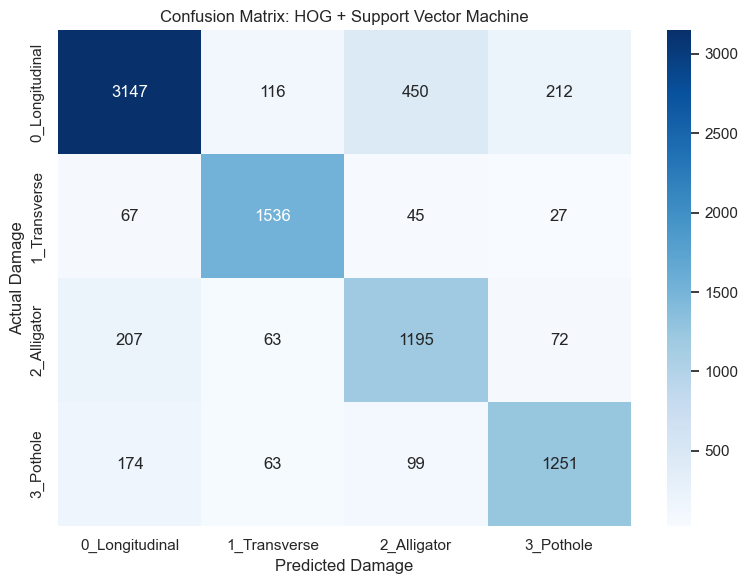

EVALUATING: LBP + Random Forest
                precision    recall  f1-score   support

0_Longitudinal       0.74      0.52      0.61      3925
  1_Transverse       0.65      0.76      0.70      1675
   2_Alligator       0.43      0.69      0.53      1537
     3_Pothole       0.63      0.64      0.63      1587

      accuracy                           0.62      8724
     macro avg       0.61      0.65      0.62      8724
  weighted avg       0.65      0.62      0.62      8724



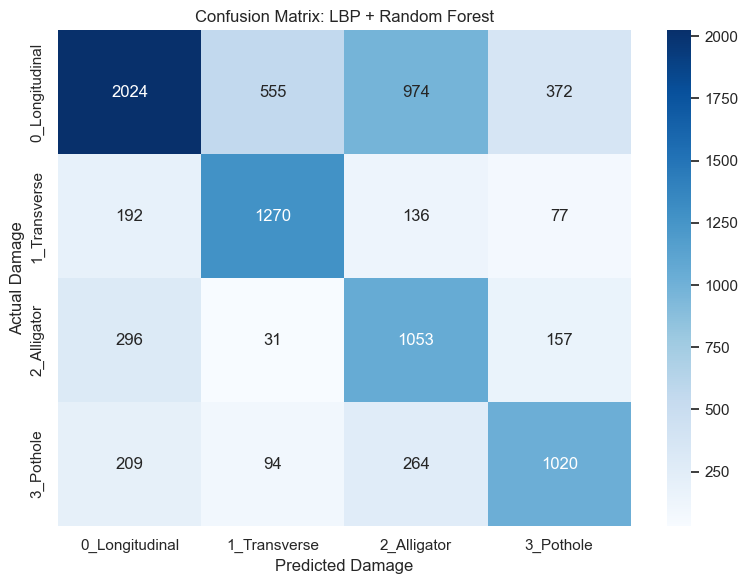

In [30]:
import os
import cv2
import numpy as np
import time
from skimage.feature import hog, local_binary_pattern
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
dataset_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_PATCHES"
classes = ["0_Longitudinal", "1_Transverse", "2_Alligator", "3_Pothole"]

# LBP Parameters (Uniform method is best for textures)
LBP_RADIUS = 3
LBP_POINTS = 24  # 8 * radius

def load_and_extract_features(split_name):
    """Reads images from a split, extracts HOG and LBP features, and returns numpy arrays."""
    split_dir = os.path.join(dataset_dir, split_name)
    
    X_hog = []
    X_lbp = []
    y = []
    
    print(f"Extracting features from '{split_name}' set...")
    start_time = time.time()
    
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.exists(class_dir):
            continue
            
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            
            if img is None:
                continue
                
            # SAFEGUARD: Force resize to 128x128 to guarantee identical HOG vector lengths
            img = cv2.resize(img, (128, 128))
            
            # ML models work best on gradients/textures, so we convert to Grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # --- 1. Extract HOG Features (For SVM) ---
            # 16x16 cells on a 128x128 image yields a concise 1,764-dimensional vector
            hog_feat = hog(gray, orientations=9, pixels_per_cell=(16, 16),
                           cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
            X_hog.append(hog_feat)
            
            # --- 2. Extract LBP Features (For Random Forest) ---
            lbp_map = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method="uniform")
            
            # FIX: Hardcode the number of bins. 
            # For 'uniform' LBP, the number of distinct patterns is exactly LBP_POINTS + 2.
            n_bins = LBP_POINTS + 2
            
            # Extract histogram using the fixed bin count
            hist, _ = np.histogram(lbp_map.ravel(), bins=n_bins, range=(0, n_bins))
            
            # Normalize the histogram so image contrast doesn't warp the results
            hist = hist.astype("float")
            hist /= (hist.sum() + 1e-7) 
            X_lbp.append(hist)
            
            y.append(class_idx)
            
    print(f"  -> Done in {time.time() - start_time:.2f} seconds.")
    return np.array(X_hog), np.array(X_lbp), np.array(y)

# --- 1. Load Data ---
X_train_hog, X_train_lbp, y_train = load_and_extract_features("train")
X_test_hog, X_test_lbp, y_test = load_and_extract_features("test")

print(f"\nTraining set size: {len(y_train)} patches")
print(f"HOG feature vector size: {X_train_hog.shape[1]}")
print(f"LBP histogram vector size: {X_train_lbp.shape[1]}\n")

# --- 2. Train Model 1: HOG + SVM ---
print("Training HOG + SVM with GridSearchCV...")
svm_start = time.time()

# Grid search to find the optimal C and gamma parameters for the RBF kernel
svm_param_grid = {'C': [1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 'auto']}
svm_grid = GridSearchCV(SVC(class_weight='balanced'), svm_param_grid, refit=True, cv=3, verbose=2, n_jobs=-1)
svm_grid.fit(X_train_hog, y_train)

print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"SVM Training Time: {time.time() - svm_start:.2f} seconds\n")

# --- 3. Train Model 2: LBP + Random Forest ---
print("Training LBP + Random Forest...")
rf_start = time.time()

# RF naturally handles class imbalance well, but class_weight='balanced' adds extra penalization
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_lbp, y_train)

print(f"Random Forest Training Time: {time.time() - rf_start:.2f} seconds\n")

# --- 4. Evaluation & Behavioral Analysis ---
def evaluate_model(model, X_test, y_test, model_name):
    print("=" * 50)
    print(f"EVALUATING: {model_name}")
    print("=" * 50)
    
    predictions = model.predict(X_test)
    print(classification_report(y_test, predictions, target_names=classes))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual Damage')
    plt.xlabel('Predicted Damage')
    plt.tight_layout()
    plt.show()

# Run evaluations
evaluate_model(svm_grid.best_estimator_, X_test_hog, y_test, "HOG + Support Vector Machine")
evaluate_model(rf_model, X_test_lbp, y_test, "LBP + Random Forest")

# Deep learning models

In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Configuration & Data Loading ---
dataset_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_PATCHES"
classes = ["0_Longitudinal", "1_Transverse", "2_Alligator", "3_Pothole"]
BATCH_SIZE = 32
EPOCHS = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Data Augmentation for training, strict resizing/normalization for val/test
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(os.path.join(dataset_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(dataset_dir, 'val'), transform=eval_transforms)
test_dataset = datasets.ImageFolder(os.path.join(dataset_dir, 'test'), transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 2. Model Architectures ---

class CustomCNN(nn.Module):
    """A standard 4-block Sequential Convolutional Neural Network"""
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # Output: 64x64
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # Output: 32x32
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), # Output: 16x16
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # Output: 8x8
        )
        
        # Global Average Pooling forces the tensor to a 1x1 spatial dimension
        # This makes the network robust to different input sizes
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

class ResidualBlock(nn.Module):
    """The fundamental building block of a ResNet"""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        # The main path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # The skip connection (Identity shortcut)
        self.shortcut = nn.Sequential()
        # If the dimensions change, we must use a 1x1 convolution to resize the skip connection to match
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Add the skip connection BEFORE the final activation function
        out += identity
        out = self.relu(out)
        
        return out

class CustomResNet(nn.Module):
    """A lightweight ResNet built from scratch"""
    def __init__(self, num_classes=4):
        super(CustomResNet, self).__init__()
        self.in_channels = 64
        
        # Initial stem
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Residual Layers
        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = []
        # First block handles the stride and channel changes
        layers.append(ResidualBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        # Remaining blocks just process at the new dimension
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x



In [ ]:
def train_model(model, model_name):
    print(f"\n{'='*50}\nStarting Training: {model_name}\n{'='*50}")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # Drops the learning rate by a factor of 0.1 if val loss stagnates for 3 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print("-" * 10)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
            
            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()
        
    print(f"Best Validation Accuracy: {best_acc:4f}")
    model.load_state_dict(best_model_wts)
    return model



In [ ]:
def evaluate_on_test_set(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print(f"\nTest Evaluation for {model_name}:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


    

In [ ]:
cnn_model = CustomCNN(num_classes=4)
resnet_model = CustomResNet(num_classes=4)
    
# Train Models
cnn_trained = train_model(cnn_model, "Custom CNN Baseline")
resnet_trained = train_model(resnet_model, "Custom ResNet")
    
# Evaluate Models
evaluate_on_test_set(cnn_trained, "Custom CNN Baseline")
evaluate_on_test_set(resnet_trained, "Custom ResNet")

# tests on dataset


Extracting dataset metrics...


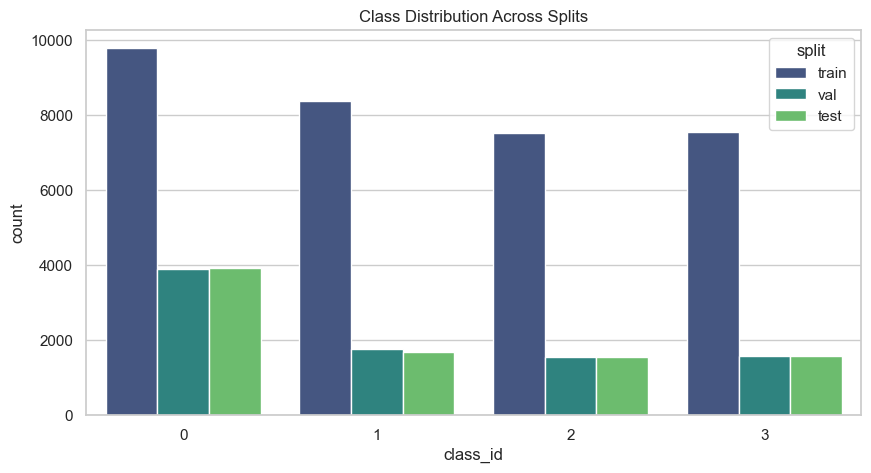

C:\Users\ssriv\AppData\Local\Temp\ipykernel_34256\645867378.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_id', y='area', palette='Set2')


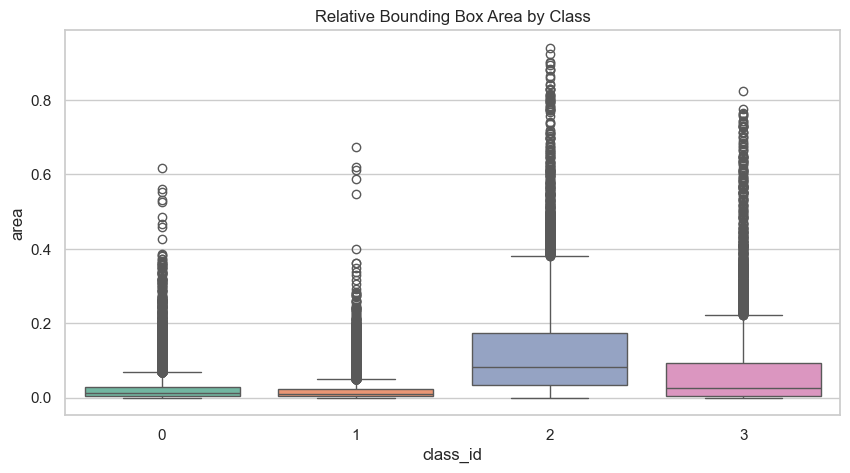

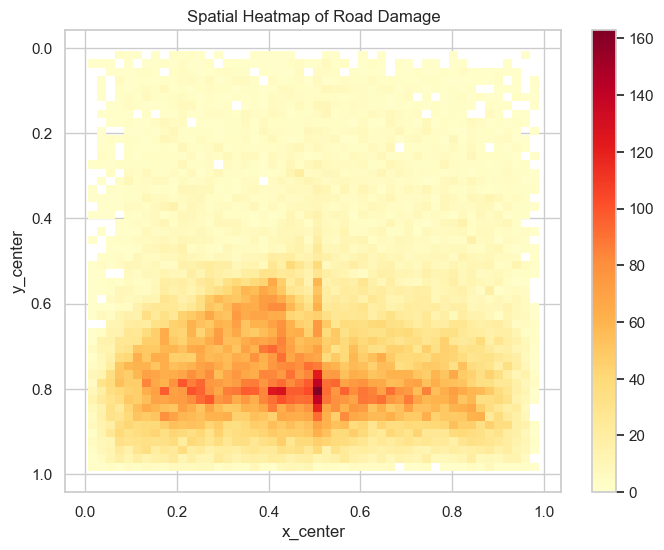


--- Summary Statistics ---
             area                                                              \
            count      mean       std       min       25%       50%       75%   
class_id                                                                        
0         17599.0  0.024446  0.039022  0.000013  0.003301  0.010910  0.028960   
1         11830.0  0.021297  0.033628  0.000022  0.005310  0.010725  0.022630   
2         10617.0  0.121717  0.123856  0.000000  0.033603  0.081700  0.172502   
3         10705.0  0.065486  0.096393  0.000003  0.004500  0.025077  0.091678   

                   aspect_ratio                                          \
               max        count      mean       std       min       25%   
class_id                                                                  
0         0.616410      17599.0  0.703025  0.572701  0.020725  0.348199   
1         0.672512      11830.0  5.663018  3.034182  0.159459  3.716464   
2         0.940847      10617

In [26]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT"
folders = ["train", "val", "test"]
data = []

print("Extracting dataset metrics...")
for folder in folders:
    labels_dir = os.path.join(base_dir, folder, "labels")
    for txt_path in glob.glob(os.path.join(labels_dir, "*.txt")):
        with open(txt_path, 'r', encoding='utf-8') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    data.append({
                        "split": folder,
                        "class_id": int(parts[0]),
                        "x_center": float(parts[1]),
                        "y_center": float(parts[2]),
                        "width": float(parts[3]),
                        "height": float(parts[4])
                    })

df = pd.DataFrame(data)
df['area'] = df['width'] * df['height']
df['aspect_ratio'] = df['width'] / df['height']

# 1. Class Distribution Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='class_id', hue='split', palette='viridis')
plt.title("Class Distribution Across Splits")
plt.show()

# 2. Bounding Box Area Distribution
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='class_id', y='area', palette='Set2')
plt.title("Relative Bounding Box Area by Class")
plt.show()

# 3. Spatial Distribution Heatmap
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='x_center', y='y_center', bins=50, cmap="YlOrRd", cbar=True)
plt.title("Spatial Heatmap of Road Damage")
plt.gca().invert_yaxis() # Invert Y to match image coordinates
plt.show()

print("\n--- Summary Statistics ---")
print(df.groupby('class_id')[['area', 'aspect_ratio']].describe())

Extracting absolute dataset metrics... (This may take a minute for 30,000+ files)

Successfully extracted data for 50,751 annotations.


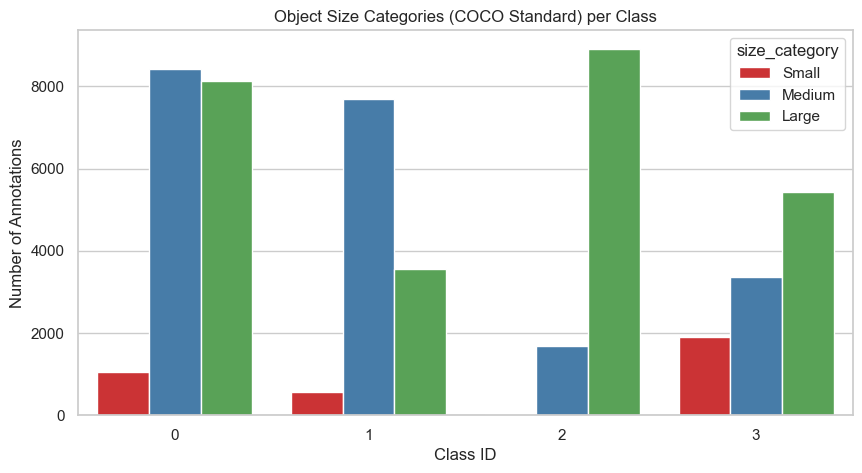

C:\Users\ssriv\AppData\Local\Temp\ipykernel_34256\438121896.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_id', y='abs_area', palette='Set2')


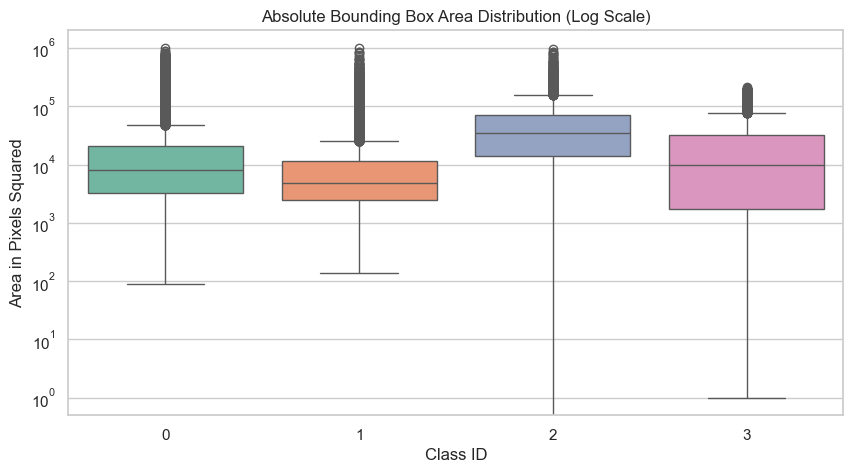

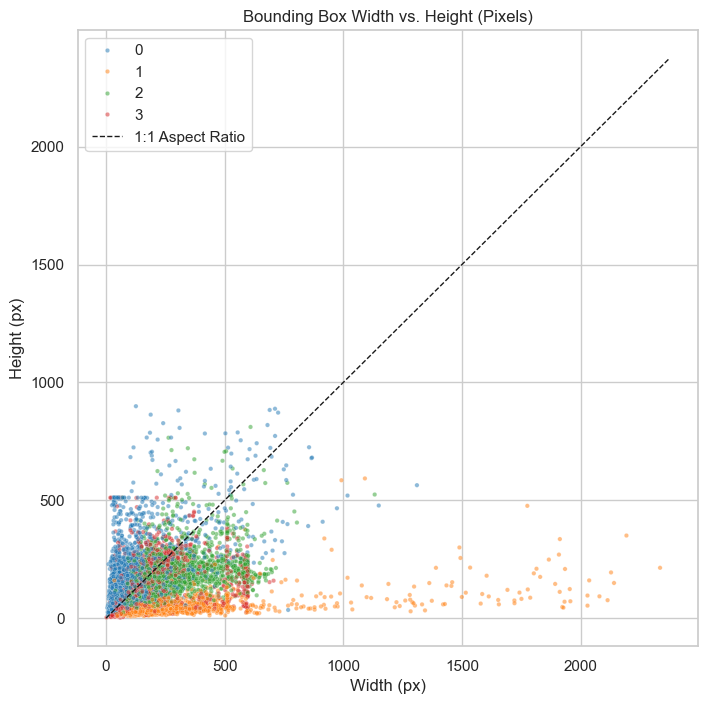


--- Absolute Area Summary Statistics (Pixels Squared) ---
            count      mean       std     min       25%       50%       75%  \
class_id                                                                      
0         17599.0  24312.51  58871.10   90.00   3240.00   8064.02  21022.30   
1         11830.0  16300.78  45809.99  140.01   2492.82   4896.00  11501.02   
2         10617.0  51654.59  58718.77    0.00  14268.03  34650.06  71141.91   
3         10705.0  22511.61  30444.35    1.00   1709.99   9768.01  32032.07   

                 max  
class_id              
0         1005170.56  
1         1001128.97  
2          952851.69  
3          216153.06  

--- Size Category Counts ---
size_category  Large  Medium  Small
class_id                           
0               8134    8420   1045
1               3559    7695    576
2               8918    1678     21
3               5442    3353   1910


In [27]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Define paths
base_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT"
folders = ["train", "val", "test"]
data = []

# COCO Area Thresholds (in pixels)
SMALL_THRESH = 32 ** 2     # 1,024 px^2
MEDIUM_THRESH = 96 ** 2    # 9,216 px^2

print("Extracting absolute dataset metrics... (This may take a minute for 30,000+ files)")

for folder in folders:
    labels_dir = os.path.join(base_dir, folder, "labels")
    images_dir = os.path.join(base_dir, folder, "images")
    
    txt_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    
    for txt_path in txt_files:
        # Match label file to image file (assuming .jpg for RDD2022)
        base_name = os.path.basename(txt_path).replace(".txt", "")
        img_path = os.path.join(images_dir, f"{base_name}.jpg")
        
        # Check if .png exists if .jpg doesn't
        if not os.path.exists(img_path):
            img_path = os.path.join(images_dir, f"{base_name}.png")
            
        if not os.path.exists(img_path):
            continue # Skip if image is missing
            
        # Get actual image dimensions (fast header read)
        try:
            with Image.open(img_path) as img:
                img_w, img_h = img.size
        except Exception:
            continue
            
        with open(txt_path, 'r', encoding='utf-8') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    # YOLO format: x_center, y_center, width, height (normalized)
                    norm_x = float(parts[1])
                    norm_y = float(parts[2])
                    norm_w = float(parts[3])
                    norm_h = float(parts[4])
                    
                    # Convert to absolute pixels
                    abs_w = norm_w * img_w
                    abs_h = norm_h * img_h
                    area_px = abs_w * abs_h
                    
                    # Categorize by COCO size standards
                    if area_px < SMALL_THRESH:
                        size_category = 'Small'
                    elif area_px < MEDIUM_THRESH:
                        size_category = 'Medium'
                    else:
                        size_category = 'Large'
                        
                    data.append({
                        "split": folder,
                        "class_id": class_id,
                        "abs_width": abs_w,
                        "abs_height": abs_h,
                        "abs_area": area_px,
                        "aspect_ratio": abs_w / abs_h if abs_h > 0 else 0,
                        "size_category": size_category
                    })

df = pd.DataFrame(data)

print(f"\nSuccessfully extracted data for {len(df):,} annotations.")

# ---------------------------------------------------------
# Visualizations
# ---------------------------------------------------------

# 1. COCO Size Distribution by Class
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='class_id', hue='size_category', 
              hue_order=['Small', 'Medium', 'Large'], palette='Set1')
plt.title("Object Size Categories (COCO Standard) per Class")
plt.xlabel("Class ID")
plt.ylabel("Number of Annotations")
plt.show()

# 2. Absolute Area Distribution (Log Scale for better visibility)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='class_id', y='abs_area', palette='Set2')
plt.yscale('log')
plt.title("Absolute Bounding Box Area Distribution (Log Scale)")
plt.xlabel("Class ID")
plt.ylabel("Area in Pixels Squared")
plt.show()

# 3. Width vs Height Scatter Plot (Identifies crack shapes)
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df.sample(min(10000, len(df))), x='abs_width', y='abs_height', 
                hue='class_id', palette='tab10', s=10, alpha=0.5)
# Add a diagonal line for perfect squares (Aspect Ratio = 1:1)
plt.plot([0, df['abs_width'].max()], [0, df['abs_width'].max()], 'k--', lw=1, label='1:1 Aspect Ratio')
plt.title("Bounding Box Width vs. Height (Pixels)")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.legend()
plt.show()

print("\n--- Absolute Area Summary Statistics (Pixels Squared) ---")
print(df.groupby('class_id')['abs_area'].describe().round(2))

print("\n--- Size Category Counts ---")
print(pd.crosstab(df['class_id'], df['size_category']))

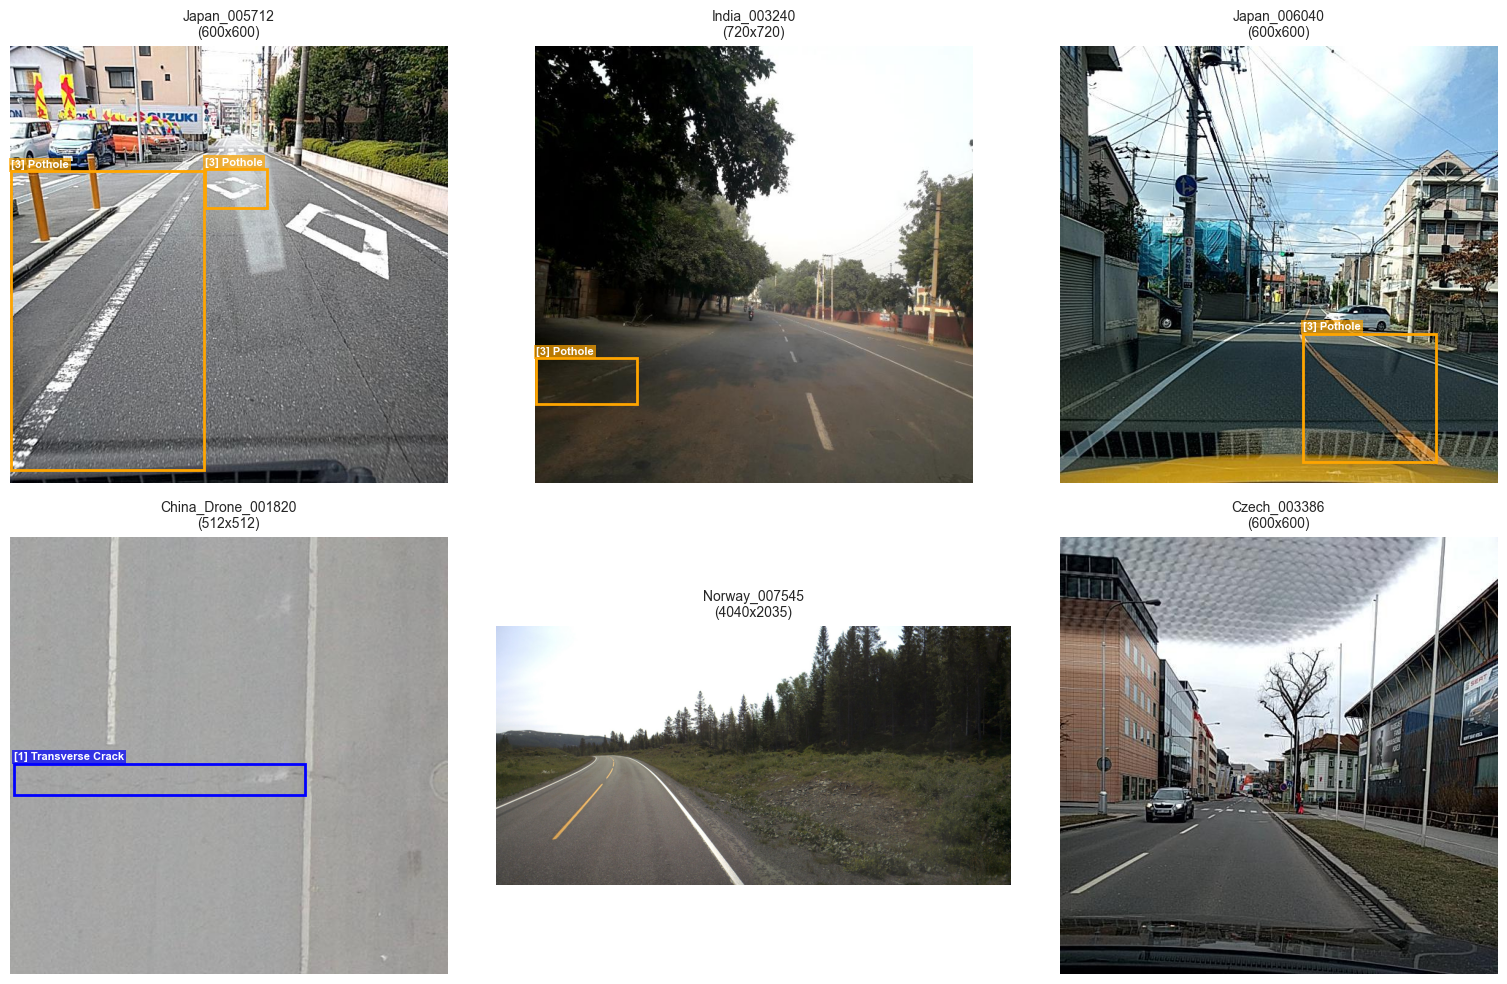

In [28]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Dataset paths
base_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT"
split = "train"  # You can change this to 'val' or 'test'
images_dir = os.path.join(base_dir, split, "images")
labels_dir = os.path.join(base_dir, split, "labels")

# In RDD2022, the 4 main damage classes generally map as follows:
# D00 (Longitudinal), D10 (Transverse), D20 (Alligator), D40 (Pothole)
class_map = {
    0: ("Longitudinal Crack", "red"),
    1: ("Transverse Crack", "blue"),
    2: ("Alligator Crack", "green"),
    3: ("Pothole", "orange")
}

# Grab all label files so we only visualize images that have annotations
label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
random.shuffle(label_files) # Shuffle to get random images each time

num_images_to_show = 6
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

count = 0
for label_file in label_files:
    if count >= num_images_to_show:
        break
        
    base_name = label_file.replace(".txt", "")
    
    # Check for .jpg or .png
    img_path = os.path.join(images_dir, f"{base_name}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(images_dir, f"{base_name}.png")
        if not os.path.exists(img_path):
            continue  # Skip if image doesn't exist
            
    label_path = os.path.join(labels_dir, label_file)
    
    # Load image and get dimensions
    img = Image.open(img_path)
    img_w, img_h = img.size
    
    ax = axes[count]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{base_name}\n({img_w}x{img_h})", fontsize=10)
    
    # Read labels and draw boxes
    with open(label_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            class_id = int(parts[0])
            if class_id not in class_map: 
                continue # Skip rogue classes if any sneaked in
            
            # Extract normalized YOLO coordinates
            x_center_norm, y_center_norm, w_norm, h_norm = map(float, parts[1:])
            
            # 1. Convert normalized width/height to absolute width/height
            box_w = w_norm * img_w
            box_h = h_norm * img_h
            
            # 2. Convert center coordinates to top-left coordinates (required by Matplotlib)
            x_min = (x_center_norm - (w_norm / 2)) * img_w
            y_min = (y_center_norm - (h_norm / 2)) * img_h
            
            class_name, color = class_map[class_id]
            
            # Draw the bounding box
            rect = patches.Rectangle(
                (x_min, y_min), box_w, box_h, 
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)
            
            # Add a background label for the text to make it readable
            ax.text(
                x_min, y_min - 5, f"[{class_id}] {class_name}", 
                color='white', fontsize=8, weight='bold', 
                bbox=dict(facecolor=color, alpha=0.7, edgecolor='none', pad=1.5)
            )
            
    count += 1

plt.tight_layout()
plt.show()

## Kruskal wallis, Chi squared tests

In [29]:
import os
import glob
import pandas as pd
import numpy as np
from scipy import stats

base_dir = r"D:\Sept-modules-assignments\AIDL docs\archive\RDD_SPLIT"
folders = ["train", "val", "test"]
data = []

print("Loading annotations for statistical testing...")

# 1. Load Data
for folder in folders:
    labels_dir = os.path.join(base_dir, folder, "labels")
    for txt_path in glob.glob(os.path.join(labels_dir, "*.txt")):
        with open(txt_path, 'r', encoding='utf-8') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    w = float(parts[3])
                    h = float(parts[4])
                    data.append({
                        "split": folder,
                        "class_id": int(parts[0]),
                        "area": w * h  # Normalized area is fine for relative statistical tests
                    })

df = pd.DataFrame(data)

print("-" * 50)
print("STATISTICAL TEST RESULTS")
print("-" * 50)

# ---------------------------------------------------------
# Test 1: Kruskal-Wallis (Area vs. Class)
# ---------------------------------------------------------
# Group areas by class
groups = [df[df['class_id'] == i]['area'].values for i in range(4) if len(df[df['class_id'] == i]) > 0]

h_stat, p_val_kw = stats.kruskal(*groups)
print(f"1. Kruskal-Wallis H-Test (Damage Size Differences by Class):")
print(f"   H-Statistic: {h_stat:.2f}, p-value: {p_val_kw:.4e}")
if p_val_kw < 0.05:
    print("   Result: SIGNIFICANT. The median sizes of different damage types vary significantly.")
    print("   Action: YOLO's anchor boxes will need to capture a wide variance in aspect ratios.")
else:
    print("   Result: NOT SIGNIFICANT. Damage sizes are statistically similar across classes.")

print("\n")

# ---------------------------------------------------------
# Test 2: Chi-Squared (Class Distribution vs. Split)
# ---------------------------------------------------------
# Create a contingency table of Class vs Split
contingency_table = pd.crosstab(df['class_id'], df['split'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"2. Chi-Squared Test (Split Bias Check):")
print(f"   Chi2-Statistic: {chi2:.2f}, p-value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("   Result: SIGNIFICANT. The ratio of classes in your train/val/test splits are NOT perfectly identical.")
    print("   Note: In highly imbalanced large datasets, small deviations flag as significant. Check the raw counts to see if the deviation is severe.")
else:
    print("   Result: NOT SIGNIFICANT. Your train, val, and test splits are perfectly balanced relative to one another.")

print("\n" + "-" * 50)
print("CLASS BALANCING FOR YOLO")
print("-" * 50)

# ---------------------------------------------------------
# Calculate Class Weights
# ---------------------------------------------------------
# Focus only on the training set to prevent data leakage
train_df = df[df['split'] == 'train']
class_counts = train_df['class_id'].value_counts().sort_index()

total_annotations = len(train_df)
num_classes = len(class_counts)

weights = {}
for cls, count in class_counts.items():
    # Inverse Frequency Weighting Formula
    weight = total_annotations / (num_classes * count)
    weights[cls] = round(weight, 4)

print("Class Counts in Training Set:")
print(class_counts.to_string())

print("\nCalculated Class Weights (Inverse Frequency):")
for cls, w in weights.items():
    print(f"   Class {cls}: {w}")

print("\nTo use these in YOLO, find the loss configuration and apply these weights.")

Loading annotations for statistical testing...
--------------------------------------------------
STATISTICAL TEST RESULTS
--------------------------------------------------
1. Kruskal-Wallis H-Test (Damage Size Differences by Class):
   H-Statistic: 11720.16, p-value: 0.0000e+00
   Result: SIGNIFICANT. The median sizes of different damage types vary significantly.
   Action: YOLO's anchor boxes will need to capture a wide variance in aspect ratios.


2. Chi-Squared Test (Split Bias Check):
   Chi2-Statistic: 1177.35, p-value: 3.8099e-251
   Result: SIGNIFICANT. The ratio of classes in your train/val/test splits are NOT perfectly identical.
   Note: In highly imbalanced large datasets, small deviations flag as significant. Check the raw counts to see if the deviation is severe.

--------------------------------------------------
CLASS BALANCING FOR YOLO
--------------------------------------------------
Class Counts in Training Set:
class_id
0    9784
1    8386
2    7527
3    7554

Cal

# XML Annotations

In [31]:
import os
import glob
import random
import shutil
import xml.etree.ElementTree as ET

# ==========================================
# Configuration
# ==========================================
input_base = r"D:\Sept-modules-assignments\AIDL docs\21431547\RDD2022_released_through_CRDDC2022\RDD2022"
output_base = r"D:\Sept-modules-assignments\AIDL docs\RDD_YOLO_CLEAN"

countries = ["United_States", "Norway", "China_Drone", "China_MotorBike", "Czech", "Japan", "India"]
splits = {"train": 0.70, "val": 0.10, "test": 0.20}
class_map = {'D00': 0, 'D10': 1, 'D20': 2, 'D40': 3}

# Create new directory structure
for split in splits.keys():
    os.makedirs(os.path.join(output_base, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(output_base, split, "labels"), exist_ok=True)

# ==========================================
# Conversion & Copy Logic
# ==========================================
total_processed = 0

for country in countries:
    print(f"Processing {country}...")
    
    # Handle potentially double-nested folders (e.g., Norway/Norway/train/)
    xml_dir = os.path.join(input_base, country, country, 'train', 'annotations', 'xmls')
    img_dir = os.path.join(input_base, country, country, 'train', 'images')
    if not os.path.exists(xml_dir):
        xml_dir = os.path.join(input_base, country, 'train', 'annotations', 'xmls')
        img_dir = os.path.join(input_base, country, 'train', 'images')
        
    xml_files = glob.glob(os.path.join(xml_dir, "*.xml"))
    
    # Only keep files that have a matching image
    valid_pairs = []
    for xml_path in xml_files:
        base_name = os.path.basename(xml_path).replace(".xml", "")
        img_path = os.path.join(img_dir, f"{base_name}.jpg")
        if not os.path.exists(img_path):
            img_path = img_path.replace(".jpg", ".png")
            
        if os.path.exists(img_path):
            valid_pairs.append((xml_path, img_path))
            
    # Stratified Shuffle
    random.seed(42)
    random.shuffle(valid_pairs)
    
    # Calculate split indices
    train_end = int(len(valid_pairs) * splits["train"])
    val_end = train_end + int(len(valid_pairs) * splits["val"])
    
    split_allocations = (
        [("train", p) for p in valid_pairs[:train_end]] +
        [("val", p) for p in valid_pairs[train_end:val_end]] +
        [("test", p) for p in valid_pairs[val_end:]]
    )
    
    for split_name, (xml_path, img_path) in split_allocations:
        base_name = os.path.basename(xml_path).replace(".xml", "")
        
        # Parse XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        size = root.find('size')
        
        if size is None: continue
        img_w = float(size.find('width').text)
        img_h = float(size.find('height').text)
        if img_w == 0 or img_h == 0: continue
        
        yolo_lines = []
        for obj in root.findall('object'):
            cls_name = obj.find('name').text
            if cls_name not in class_map: continue
            
            cls_id = class_map[cls_name]
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            
            # Flawless YOLO Math Conversion
            x_center = ((xmin + xmax) / 2) / img_w
            y_center = ((ymin + ymax) / 2) / img_h
            box_w = (xmax - xmin) / img_w
            box_h = (ymax - ymin) / img_h
            
            # Clip values between 0 and 1
            x_center, y_center = max(0.0, min(1.0, x_center)), max(0.0, min(1.0, y_center))
            box_w, box_h = max(0.0, min(1.0, box_w)), max(0.0, min(1.0, box_h))
            
            yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}\n")
            
        # Only copy image and write label if there is valid damage
        if yolo_lines:
            # Write labels
            label_out_path = os.path.join(output_base, split_name, "labels", f"{base_name}.txt")
            with open(label_out_path, 'w') as f:
                f.writelines(yolo_lines)
                
            # Copy image
            img_out_path = os.path.join(output_base, split_name, "images", os.path.basename(img_path))
            shutil.copy(img_path, img_out_path)
            
            total_processed += 1

print("=" * 50)
print(f"PIPELINE COMPLETE! Extracted and formatted {total_processed:,} valid images.")

Processing United_States...
Processing Norway...
Processing China_Drone...
Processing China_MotorBike...
Processing Czech...
Processing Japan...
Processing India...
PIPELINE COMPLETE! Extracted and formatted 23,767 valid images.


## quantitative statistical tests

In [32]:
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from scipy import stats
import warnings

# Suppress minor scipy warnings for clean output
warnings.filterwarnings('ignore')

# ==========================================
# 1. Configuration & Complex Directory Traversal
# ==========================================
base_dir = r"D:\Sept-modules-assignments\AIDL docs\21431547\RDD2022_released_through_CRDDC2022\RDD2022"
countries = ["United_States", "Norway", "China_Drone", "China_MotorBike", "Czech", "Japan", "India"]

data = []
print("Crawling nested country directories and parsing XML files...")

for country in countries:
    # Dynamically handle single vs. double-nested country folders
    xml_dir = os.path.join(base_dir, country, country, 'train', 'annotations', 'xmls')
    if not os.path.exists(xml_dir):
        xml_dir = os.path.join(base_dir, country, 'train', 'annotations', 'xmls')
        
    xml_files = glob.glob(os.path.join(xml_dir, "*.xml"))
    
    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            
            # Get image dimensions
            size = root.find('size')
            if size is not None:
                img_w = int(size.find('width').text)
                img_h = int(size.find('height').text)
                img_area = img_w * img_h
            else:
                continue
                
            for obj in root.findall('object'):
                class_name = obj.find('name').text
                
                # Filter for the main RDD classes (D00, D10, D20, D40)
                if class_name not in ['D00', 'D10', 'D20', 'D40']:
                    continue
                    
                bndbox = obj.find('bndbox')
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)
                
                # Calculate metrics
                box_w = max(xmax - xmin, 1.0) 
                box_h = max(ymax - ymin, 1.0) 
                abs_area = box_w * box_h
                aspect_ratio = box_w / box_h
                normalized_area = abs_area / img_area if img_area > 0 else 0
                
                data.append({
                    "country": country,
                    "class_name": class_name,
                    "box_width": box_w,
                    "box_height": box_h,
                    "abs_area": abs_area,
                    "aspect_ratio": aspect_ratio,
                    "normalized_area": normalized_area
                })
                
        except Exception:
            continue # Skip malformed XMLs

df = pd.DataFrame(data)
print(f"Successfully extracted {len(df):,} valid annotations.")

print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS SUITE")
print("=" * 60)

# ==========================================
# 2. ANOVA & Kruskal-Wallis (Size Comparison)
# ==========================================
print("\n[TEST 1 & 2: Damage Size Variances]")
groups = [df[df['class_name'] == c]['normalized_area'].values for c in ['D00', 'D10', 'D20', 'D40']]

f_stat, p_anova = stats.f_oneway(*groups)
print(f"-> ANOVA (F-Statistic): {f_stat:.2f} | p-value: {p_anova:.4e}")

h_stat, p_kw = stats.kruskal(*groups)
print(f"-> Kruskal-Wallis (H-Statistic): {h_stat:.2f} | p-value: {p_kw:.4e}")
if p_kw < 0.05:
    print("   Result: SIGNIFICANT. Bounding box sizes are statistically distinct across classes.")

# ==========================================
# 3. Levene's Test (Variance/Consistency)
# ==========================================
print("\n[TEST 3: Variance Consistency]")
l_stat, p_levene = stats.levene(*groups)
print(f"-> Levene's Test (Statistic): {l_stat:.2f} | p-value: {p_levene:.4e}")
if p_levene < 0.05:
    print("   Result: SIGNIFICANT. The variance in size differs drastically between classes.")

# ==========================================
# 4. Chi-Squared Test of Independence
# ==========================================
print("\n[TEST 4: Geographical Bias]")
contingency_table = pd.crosstab(df['country'], df['class_name'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"-> Chi-Squared (Statistic): {chi2:.2f} | p-value: {p_chi:.4e}")
if p_chi < 0.05:
    print("   Result: SIGNIFICANT. Damage types are highly dependent on the country.")
    print("\n   [Contingency Table (Observed Counts)]:")
    print(contingency_table)

# ==========================================
# 5. Kolmogorov-Smirnov (K-S) Test
# ==========================================
print("\n[TEST 5: Shape Profile Comparison (D00 vs D10)]")
d00_aspect = df[df['class_name'] == 'D00']['aspect_ratio']
d10_aspect = df[df['class_name'] == 'D10']['aspect_ratio']

ks_stat, p_ks = stats.ks_2samp(d00_aspect, d10_aspect)
print(f"-> Two-Sample K-S Test (Statistic): {ks_stat:.4f} | p-value: {p_ks:.4e}")
if p_ks < 0.05:
    print("   Result: SIGNIFICANT. The distributions of aspect ratios are fundamentally different.")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")

Crawling nested country directories and parsing XML files...
Successfully extracted 55,007 valid annotations.

STATISTICAL ANALYSIS SUITE

[TEST 1 & 2: Damage Size Variances]
-> ANOVA (F-Statistic): 6690.81 | p-value: 0.0000e+00
-> Kruskal-Wallis (H-Statistic): 14104.33 | p-value: 0.0000e+00
   Result: SIGNIFICANT. Bounding box sizes are statistically distinct across classes.

[TEST 3: Variance Consistency]
-> Levene's Test (Statistic): 4453.80 | p-value: 0.0000e+00
   Result: SIGNIFICANT. The variance in size differs drastically between classes.

[TEST 4: Geographical Bias]
-> Chi-Squared (Statistic): 22446.09 | p-value: 0.0000e+00
   Result: SIGNIFICANT. Damage types are highly dependent on the country.

   [Contingency Table (Observed Counts)]:
class_name        D00   D10   D20   D40
country                                
China_Drone      1426  1263   293    86
China_MotorBike  2678  1096   641   235
Czech             988   399   161   197
India            1555    68  2021  3187
Ja

### visualizing statistical analysis test results

<Figure size 1200x700 with 0 Axes>

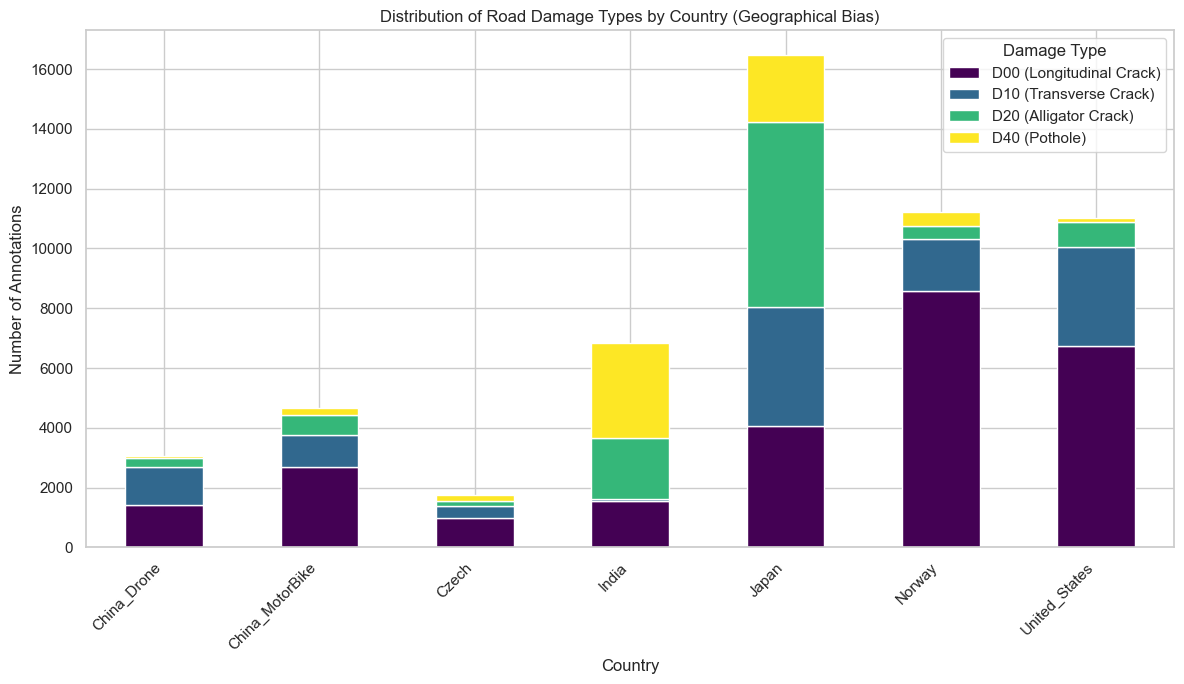

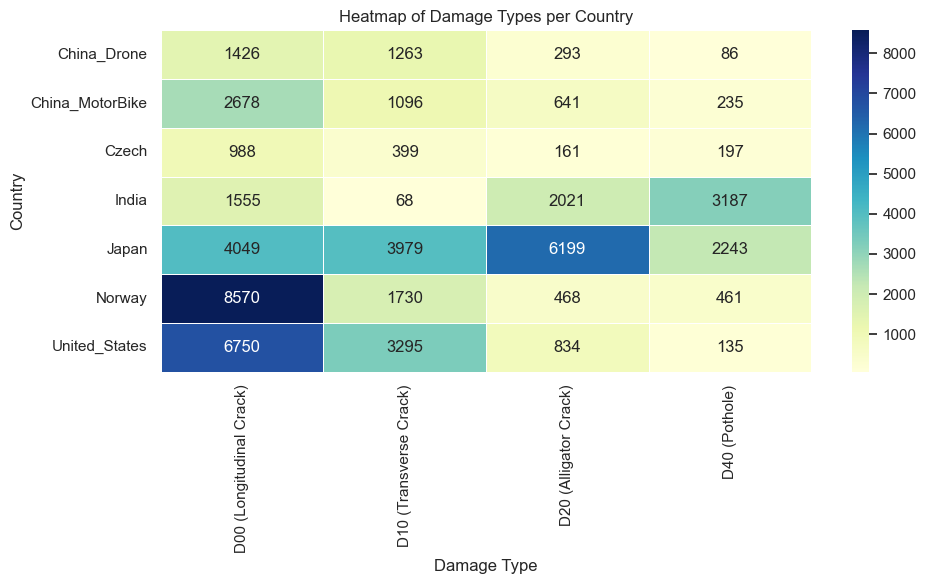

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reconstruct the contingency table from the statistical test output
data = {
    'Country': ['China_Drone', 'China_MotorBike', 'Czech', 'India', 'Japan', 'Norway', 'United_States'],
    'D00 (Longitudinal Crack)': [1426, 2678, 988, 1555, 4049, 8570, 6750],
    'D10 (Transverse Crack)': [1263, 1096, 399, 68, 3979, 1730, 3295],
    'D20 (Alligator Crack)': [293, 641, 161, 2021, 6199, 468, 834],
    'D40 (Pothole)': [86, 235, 197, 3187, 2243, 461, 135]
}

# Create DataFrame and set Country as the index
df = pd.DataFrame(data)
df.set_index('Country', inplace=True)

# ==========================================
# Plot 1: Stacked Bar Chart (Geographical Bias)
# ==========================================
plt.figure(figsize=(12, 7))
df.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 7))
plt.title('Distribution of Road Damage Types by Country (Geographical Bias)')
plt.ylabel('Number of Annotations')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Damage Type')
plt.tight_layout()
plt.savefig('geographical_bias_bar.png')
plt.show()

# ==========================================
# Plot 2: Heatmap of the Contingency Table
# ==========================================
plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap of Damage Types per Country')
plt.ylabel('Country')
plt.xlabel('Damage Type')
plt.tight_layout()
plt.savefig('geographical_bias_heatmap.png')
plt.show()

## data preprocessing for machine learning

In [34]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from imblearn.over_sampling import SMOTE
import glob

# ==========================================
# Configuration
# ==========================================
dataset_base = r"D:\Sept-modules-assignments\AIDL docs\RDD_YOLO_CLEAN"
splits = ["train", "val", "test"]
# Fixed size for HOG consistency 
# (64x64 is standard for balancing detail and computational load)
TARGET_SIZE = (64, 64) 

def process_split(split_name):
    print(f"Extracting features from {split_name} split...")
    X, y = [], []
    
    label_dir = os.path.join(dataset_base, split_name, "labels")
    image_dir = os.path.join(dataset_base, split_name, "images")
    
    label_files = glob.glob(os.path.join(label_dir, "*.txt"))
    
    for label_path in label_files:
        base_name = os.path.basename(label_path).replace(".txt", "")
        # Try both common extensions
        img_path = os.path.join(image_dir, f"{base_name}.jpg")
        if not os.path.exists(img_path):
            img_path = img_path.replace(".jpg", ".png")
            
        if not os.path.exists(img_path):
            continue
            
        # Read image
        img = cv2.imread(img_path)
        if img is None: continue
        img_h, img_w = img.shape[:2]
        
        # Parse YOLO labels
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5: continue
            
            cls_id = int(parts[0])
            x_center, y_center, w, h = map(float, parts[1:])
            
            # Convert YOLO (normalized) back to absolute pixel coordinates
            xmin = int((x_center - w / 2) * img_w)
            ymin = int((y_center - h / 2) * img_h)
            xmax = int((x_center + w / 2) * img_w)
            ymax = int((y_center + h / 2) * img_h)
            
            # Ensure coordinates are within image boundaries
            xmin, ymin = max(0, xmin), max(0, ymin)
            xmax, ymax = min(img_w, xmax), min(img_h, ymax)
            
            # Skip invalid crops
            if xmax <= xmin or ymax <= ymin: continue
            
            # Crop the bounding box
            crop = img[ymin:ymax, xmin:xmax]
            
            # Convert to Grayscale and Resize for HOG
            gray_crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            resized_crop = cv2.resize(gray_crop, TARGET_SIZE)
            
            # Extract HOG Features
            features = hog(resized_crop, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
            
            X.append(features)
            y.append(cls_id)
            
    return np.array(X), np.array(y)

# ==========================================
# Execution & SMOTE Balancing
# ==========================================
# 1. Extract features for all splits
X_train, y_train = process_split("train")
X_val, y_val = process_split("val")
X_test, y_test = process_split("test")

print("-" * 50)
print(f"Original Training Shape: X={X_train.shape}, y={y_train.shape}")

# 2. Apply SMOTE only to the training data to fix class imbalance
print("Applying SMOTE to balance training classes...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Balanced Training Shape: X={X_train_balanced.shape}, y={y_train_balanced.shape}")

# 3. Save the processed arrays for model training
print("Saving feature arrays...")
os.makedirs("processed_ml_data", exist_ok=True)
np.save("processed_ml_data/X_train.npy", X_train_balanced)
np.save("processed_ml_data/y_train.npy", y_train_balanced)
np.save("processed_ml_data/X_val.npy", X_val)
np.save("processed_ml_data/y_val.npy", y_val)
np.save("processed_ml_data/X_test.npy", X_test)
np.save("processed_ml_data/y_test.npy", y_test)

print("=" * 50)
print("FEATURE EXTRACTION COMPLETE! Data is ready for ML models.")

Extracting features from train split...
Extracting features from val split...
Extracting features from test split...
--------------------------------------------------
Original Training Shape: X=(38256, 1764), y=(38256,)
Applying SMOTE to balance training classes...
Balanced Training Shape: X=(72260, 1764), y=(72260,)
Saving feature arrays...
FEATURE EXTRACTION COMPLETE! Data is ready for ML models.


## Machine learning models intiation and training and testing

In [35]:
import numpy as np
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# 1. Load the Processed Data
# ==========================================
print("Loading HOG features...")
X_train = np.load("processed_ml_data/X_train.npy")
y_train = np.load("processed_ml_data/y_train.npy")
X_test = np.load("processed_ml_data/X_test.npy")
y_test = np.load("processed_ml_data/y_test.npy")

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# ==========================================
# 2. Feature Scaling
# ==========================================
# SVMs are distance-based and highly sensitive to feature scales. 
# We fit the scaler ONLY on the training data to prevent data leakage.
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. Initialize and Train Models
# ==========================================
print("\nInitializing models...")
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training SVM (This may take a while depending on data size)...")
svm_model.fit(X_train_scaled, y_train)

print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# ==========================================
# 4. Evaluation and Comparison
# ==========================================
print("\n" + "="*50)
print("MODEL EVALUATION ON TEST SET")
print("="*50)

# Class names mapping based on your initial configuration
target_names = ['D00 (Longitudinal)', 'D10 (Transverse)', 'D20 (Alligator)', 'D40 (Pothole)']

# Evaluate SVM
svm_preds = svm_model.predict(X_test_scaled)
print("\nSupport Vector Machine (SVM) Performance:")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print(classification_report(y_test, svm_preds, target_names=target_names))

# Evaluate Random Forest
rf_preds = rf_model.predict(X_test_scaled)
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds, target_names=target_names))

Loading HOG features...
Training set: 72260 samples
Test set: 11240 samples
Scaling features...

Initializing models...
Training SVM (This may take a while depending on data size)...
Training Random Forest...

MODEL EVALUATION ON TEST SET

Support Vector Machine (SVM) Performance:
Accuracy: 0.7815
                    precision    recall  f1-score   support

D00 (Longitudinal)       0.81      0.87      0.84      5372
  D10 (Transverse)       0.86      0.88      0.87      2350
   D20 (Alligator)       0.65      0.60      0.62      2147
     D40 (Pothole)       0.72      0.57      0.64      1371

          accuracy                           0.78     11240
         macro avg       0.76      0.73      0.74     11240
      weighted avg       0.78      0.78      0.78     11240


Random Forest Performance:
Accuracy: 0.7066
                    precision    recall  f1-score   support

D00 (Longitudinal)       0.76      0.81      0.79      5372
  D10 (Transverse)       0.83      0.83      0.83   

## Deep learning models initiation and testing

In [36]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 small model for transfer learning
model = YOLO('yolov8s.pt')

# Train the model (adjust batch size based on your GPU VRAM)
results = model.train(data='rdd.yaml', epochs=10, imgsz=640, batch=16, workers=4)

Ultralytics 8.4.152  Python-3.13.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=rdd.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=

In [1]:
import os
import glob
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class RDDCropDataset(Dataset):
    def __init__(self, dataset_base, split='train', transform=None):
        self.samples = []
        self.transform = transform
        
        label_dir = os.path.join(dataset_base, split, "labels")
        image_dir = os.path.join(dataset_base, split, "images")
        
        label_files = glob.glob(os.path.join(label_dir, "*.txt"))
        
        for label_path in label_files:
            base_name = os.path.basename(label_path).replace(".txt", "")
            img_path = os.path.join(image_dir, f"{base_name}.jpg")
            if not os.path.exists(img_path):
                img_path = img_path.replace(".jpg", ".png")
            if not os.path.exists(img_path):
                continue
                
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5: 
                    continue
                cls_id = int(parts[0])
                x_center, y_center, w, h = map(float, parts[1:])
                self.samples.append((img_path, cls_id, x_center, y_center, w, h))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        img_path, cls_id, x_center, y_center, w, h = self.samples[idx]
        img = cv2.imread(img_path)
        if img is None:
            # Create a black dummy image in case of unreadable file
            crop = torch.zeros((3, 224, 224), dtype=torch.float32)
            return crop, cls_id
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_h, img_w = img.shape[:2]
        
        # Calculate pixel coordinates
        xmin = max(0, int((x_center - w / 2) * img_w))
        ymin = max(0, int((y_center - h / 2) * img_h))
        xmax = min(img_w, int((x_center + w / 2) * img_w))
        ymax = min(img_h, int((y_center + h / 2) * img_h))
        
        if xmax <= xmin or ymax <= ymin:
            crop = cv2.resize(img, (224, 224))
        else:
            crop = img[ymin:ymax, xmin:xmax]
            crop = cv2.resize(crop, (224, 224))
            
        if self.transform:
            crop = self.transform(crop)
            
        return crop, cls_id

# ==========================================
# Transformations & Data Loaders Setup
# ==========================================
dataset_base = r"D:\Sept-modules-assignments\AIDL docs\RDD_YOLO_CLEAN"

# Training transforms with Augmentation to fight class imbalance
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (Deterministic)
val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = RDDCropDataset(dataset_base, split='train', transform=train_transforms)
val_dataset   = RDDCropDataset(dataset_base, split='val', transform=val_transforms)
test_dataset  = RDDCropDataset(dataset_base, split='test', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import ResNet50_Weights, EfficientNet_B0_Weights
from sklearn.metrics import classification_report
from tqdm import tqdm # Added for progress tracking

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Compute Class Weights to handle Imbalance
# (Counts approximated from initial dataset statistics)
class_counts = torch.tensor([25516.0, 11760.0, 10624.0, 6409.0])
class_weights = 1.0 / class_counts
class_weights = (class_weights / class_weights.sum()).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

def train_and_evaluate(model_name='resnet50', epochs=10):
    print(f"\n Initializing {model_name.upper()}...")
    
    if model_name == 'resnet50':
        model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 4)
    elif model_name == 'efficientnet':
        model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, 4)
        
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    
    # Training Loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        loop = tqdm(train_loader, leave=True, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
            # Update progress bar with current loss
            loop.set_postfix(loss=loss.item())
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] Completed - Avg Loss: {epoch_loss:.4f}")
        
    # Evaluation on Test Set
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    target_names = ['D00 (Longitudinal)', 'D10 (Transverse)', 'D20 (Alligator)', 'D40 (Pothole)']
    print(f"\n--- {model_name.upper()} Test Set Performance ---")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    return model

# Train both PyTorch models
resnet_model = train_and_evaluate('resnet50', epochs=10)
effnet_model = train_and_evaluate('efficientnet', epochs=10)

Using device: cuda

 Initializing RESNET50...


Epoch 1/10: 100%|██████████| 1196/1196 [12:22<00:00,  1.61it/s, loss=0.0986]


Epoch [1/10] Completed - Avg Loss: 0.4012


Epoch 2/10: 100%|██████████| 1196/1196 [11:22<00:00,  1.75it/s, loss=0.737] 


Epoch [2/10] Completed - Avg Loss: 0.2490


...

Epoch [8/10] Completed - Avg Loss: 0.0917


Epoch 9/10: 100%|██████████| 1196/1196 [08:10<00:00,  2.44it/s, loss=0.0295] 


Epoch [9/10] Completed - Avg Loss: 0.0770


Epoch 10/10: 100%|██████████| 1196/1196 [09:42<00:00,  2.05it/s, loss=0.0638] 


Epoch [10/10] Completed - Avg Loss: 0.0705

--- EFFICIENTNET Test Set Performance ---
                    precision    recall  f1-score   support

D00 (Longitudinal)       0.96      0.93      0.94      5372
  D10 (Transverse)       0.93      0.96      0.95      2350
   D20 (Alligator)       0.89      0.92      0.91      2147
     D40 (Pothole)       0.90      0.94      0.92      1371

          accuracy                           0.93     11240
         macro avg       0.92      0.94      0.93     11240
      weighted avg       0.93      0.93      0.93     11240



### validation and testing

In [38]:
# Evaluate on the unseen test split
metrics = model.val(split='test')
print(f"Test mAP50-95: {metrics.box.map}")
print(f"Test mAP50: {metrics.box.map50}")

Ultralytics 8.4.152  Python-3.13.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1015.0471.9 MB/s, size: 61.7 KB)
val: Scanning D:\Sept-modules-assignments\AIDL docs\RDD_YOLO_CLEAN\test\labels... 4800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4800/4800 3.4Kit/s 1.4s0.0s
val: New cache created: D:\Sept-modules-assignments\AIDL docs\RDD_YOLO_CLEAN\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 300/300 8.0it/s 37.7s0.1ss
                   all       4800      11240      0.568      0.482        0.5      0.241
                   D00       2754       5372      0.539      0.503      0.497      0.255
                   D10       1535       2350      0.534      0.494      0.484      0.222
                   D20       1698       2147      0.574      0.595 

Extracting absolute dataset metrics... (This may take a minute)

Successfully extracted data for 55,007 annotations.

STATISTICAL ANALYSIS SUITE
1. CHI-SQUARE TEST (Country vs. Damage Type)
   Chi-Square Statistic: 22106.6517 | P-value: 0.0000e+00
   Result: Significant dependency.

2. ONE-WAY ANOVA (Damage Type vs. Absolute Area)
   F-Statistic: 1012.6393 | P-value: 0.0000e+00
   Result: Significant size difference.

3. INDEPENDENT T-TEST (D00 vs. D10 Aspect Ratio)
   T-Statistic: -139.6765 | P-value: 0.0000e+00
   Result: Significant shape difference.


C:\Users\ssriv\AppData\Local\Temp\ipykernel_22260\1012269811.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_name', y='abs_area', ax=axes[1], palette="Set2", showfliers=False)
C:\Users\ssriv\AppData\Local\Temp\ipykernel_22260\1012269811.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['class_id'].isin([0, 1])], x='class_name', y='aspect_ratio', ax=axes[2], palette="pastel", inner="quartile")


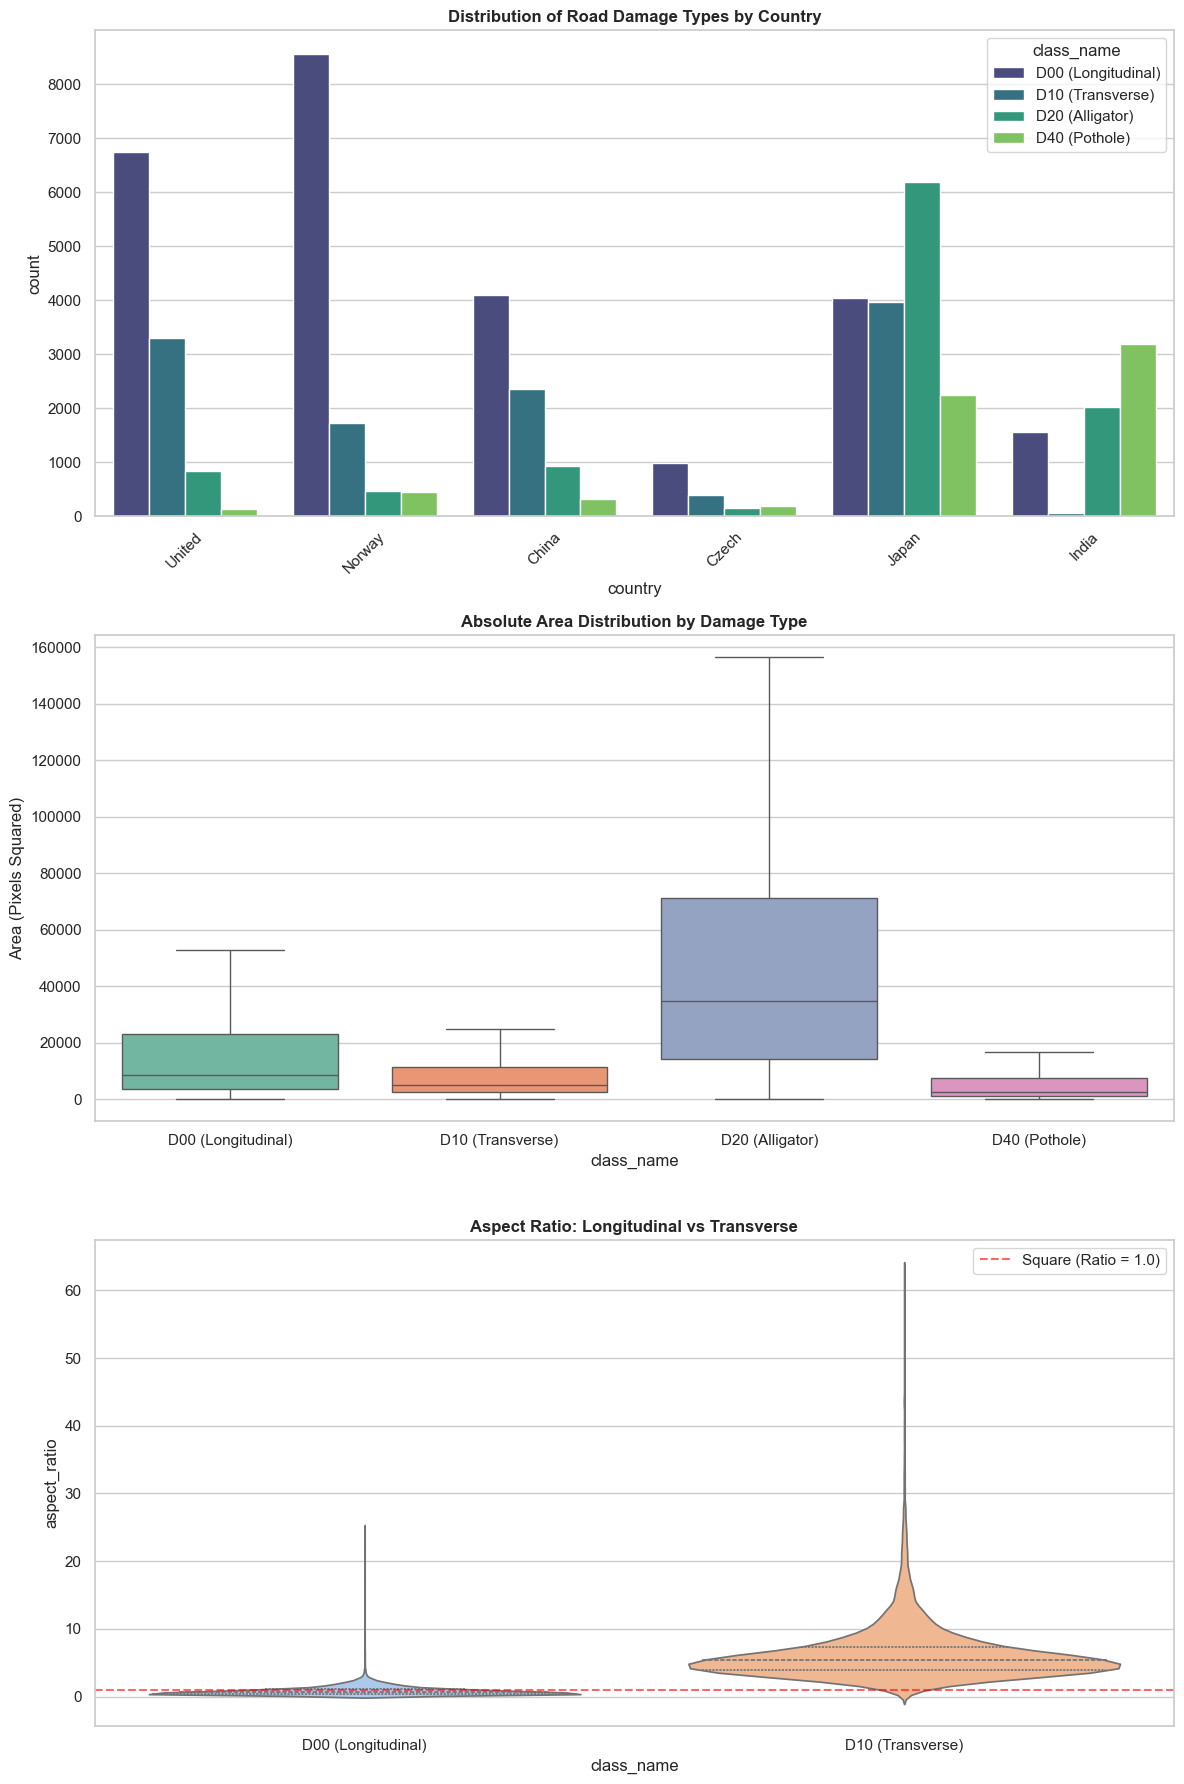

In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from PIL import Image

# ==========================================
# 1. Configuration & Data Extraction
# ==========================================
base_dir = r"D:\Sept-modules-assignments\AIDL docs\RDD_YOLO_CLEAN"
folders = ["train", "val", "test"]

CLASS_MAP = {
    0: 'D00 (Longitudinal)',
    1: 'D10 (Transverse)',
    2: 'D20 (Alligator)',
    3: 'D40 (Pothole)'
}

# COCO Area Thresholds (in pixels)
SMALL_THRESH = 32 ** 2     # 1,024 px^2
MEDIUM_THRESH = 96 ** 2    # 9,216 px^2

data = []
print("Extracting absolute dataset metrics... (This may take a minute)")

for folder in folders:
    labels_dir = os.path.join(base_dir, folder, "labels")
    images_dir = os.path.join(base_dir, folder, "images")
    
    txt_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    
    for txt_path in txt_files:
        base_name = os.path.basename(txt_path).replace(".txt", "")
        # Extract country assuming format like "Japan_0001.txt"
        country = base_name.split('_')[0] if '_' in base_name else 'Unknown'
        
        img_path = os.path.join(images_dir, f"{base_name}.jpg")
        if not os.path.exists(img_path):
            img_path = os.path.join(images_dir, f"{base_name}.png")
            
        if not os.path.exists(img_path):
            continue 
            
        # Get actual image dimensions
        try:
            with Image.open(img_path) as img:
                img_w, img_h = img.size
        except Exception:
            continue
            
        with open(txt_path, 'r', encoding='utf-8') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    if class_id not in CLASS_MAP: continue
                    
                    norm_w = float(parts[3])
                    norm_h = float(parts[4])
                    
                    # Convert to absolute pixels
                    abs_w = norm_w * img_w
                    abs_h = norm_h * img_h
                    area_px = abs_w * abs_h
                    aspect_ratio = abs_w / abs_h if abs_h > 0 else 0
                    
                    # COCO Size Category
                    if area_px < SMALL_THRESH: size_category = 'Small'
                    elif area_px < MEDIUM_THRESH: size_category = 'Medium'
                    else: size_category = 'Large'
                        
                    data.append({
                        "split": folder,
                        "country": country,
                        "class_id": class_id,
                        "class_name": CLASS_MAP[class_id],
                        "abs_area": area_px,
                        "aspect_ratio": aspect_ratio,
                        "size_category": size_category
                    })

df = pd.DataFrame(data)
print(f"\nSuccessfully extracted data for {len(df):,} annotations.")

# ==========================================
# 2. Statistical Testing
# ==========================================
print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS SUITE")
print("=" * 60)

# Chi-Square Test
contingency_table = pd.crosstab(df['country'], df['class_name'])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency_table)
print("1. CHI-SQUARE TEST (Country vs. Damage Type)")
print(f"   Chi-Square Statistic: {chi2:.4f} | P-value: {p_chi:.4e}")
print("   Result:", "Significant dependency." if p_chi < 0.05 else "Independent.")

# ANOVA Test
groups = [df[df['class_id'] == cid]['abs_area'].values for cid in CLASS_MAP.keys()]
f_stat, p_anova = stats.f_oneway(*groups)
print("\n2. ONE-WAY ANOVA (Damage Type vs. Absolute Area)")
print(f"   F-Statistic: {f_stat:.4f} | P-value: {p_anova:.4e}")
print("   Result:", "Significant size difference." if p_anova < 0.05 else "No size difference.")

# T-Test (D00 vs D10)
d00_aspect = df[df['class_id'] == 0]['aspect_ratio']
d10_aspect = df[df['class_id'] == 1]['aspect_ratio']
t_stat, p_t = stats.ttest_ind(d00_aspect, d10_aspect, equal_var=False)
print("\n3. INDEPENDENT T-TEST (D00 vs. D10 Aspect Ratio)")
print(f"   T-Statistic: {t_stat:.4f} | P-value: {p_t:.4e}")
print("   Result:", "Significant shape difference." if p_t < 0.05 else "No shape difference.")
print("=" * 60)

# ==========================================
# 3. Visualizations
# ==========================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Chi-Square Plot
sns.countplot(data=df, x='country', hue='class_name', ax=axes[0], palette="viridis")
axes[0].set_title('Distribution of Road Damage Types by Country', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# ANOVA Plot
sns.boxplot(data=df, x='class_name', y='abs_area', ax=axes[1], palette="Set2", showfliers=False)
axes[1].set_title('Absolute Area Distribution by Damage Type', fontweight='bold')
axes[1].set_ylabel('Area (Pixels Squared)')

# T-Test Plot
sns.violinplot(data=df[df['class_id'].isin([0, 1])], x='class_name', y='aspect_ratio', ax=axes[2], palette="pastel", inner="quartile")
axes[2].set_title('Aspect Ratio: Longitudinal vs Transverse', fontweight='bold')
axes[2].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Square (Ratio = 1.0)')
axes[2].legend()

plt.tight_layout()
plt.show()

Generating Confusion Matrices...


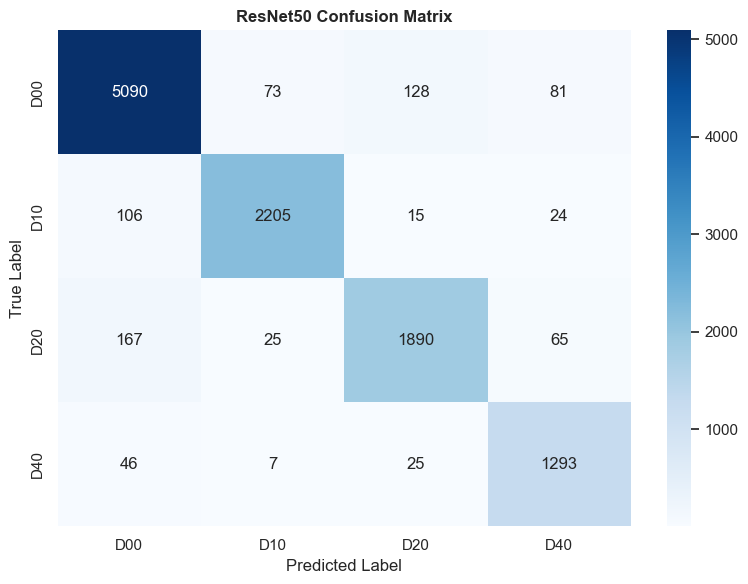

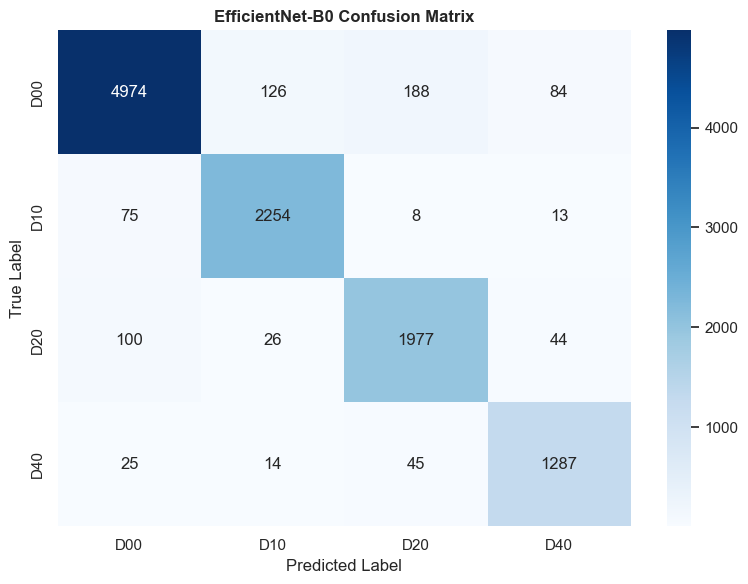

Generating Grad-CAM visualizations...


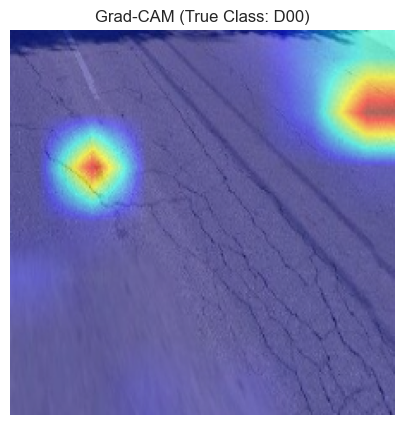

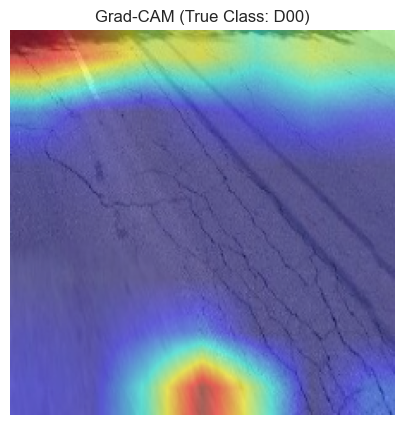

Generating SHAP explanations (this may take a moment)...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4481792..1.8267832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3850982..1.073294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5071026..1.2959158].


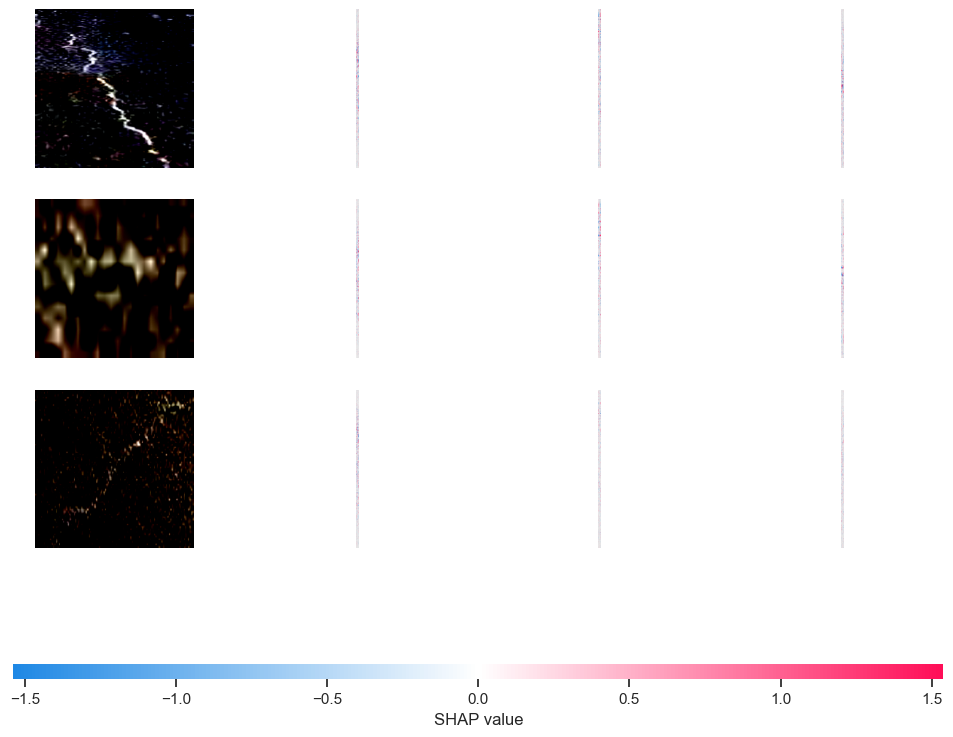

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import shap

# Assume test_loader, device, resnet_model, and effnet_model are loaded from your previous script
target_names = ['D00', 'D10', 'D20', 'D40']

# ==========================================
# 1. Confusion Matrices
# ==========================================
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(title, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

print("Generating Confusion Matrices...")
y_true, y_pred_res = get_predictions(resnet_model, test_loader)
plot_confusion_matrix(y_true, y_pred_res, "ResNet50 Confusion Matrix", "cm_resnet.png")

y_true, y_pred_eff = get_predictions(effnet_model, test_loader)
plot_confusion_matrix(y_true, y_pred_eff, "EfficientNet-B0 Confusion Matrix", "cm_effnet.png")

# ==========================================
# 2. Grad-CAM (Gradient-weighted Class Activation Mapping)
# ==========================================
def generate_gradcam(model, target_layers, image_tensor, original_image, label):
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(label)]
    
    # Generate heatmap
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0), targets=targets)[0, :]
    
    # Overlay on original image
    img_normalized = np.float32(original_image) / 255.0
    cam_image = show_cam_on_image(img_normalized, grayscale_cam, use_rgb=True)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(cam_image)
    plt.title(f"Grad-CAM (True Class: {target_names[label]})")
    plt.axis('off')
    plt.show()

print("Generating Grad-CAM visualizations...")
# Get a single batch to visualize
images, labels = next(iter(test_loader))
sample_img, sample_label = images[0], labels[0].item()

# Un-normalize image for visualization
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
visual_img = inv_normalize(sample_img).permute(1, 2, 0).numpy()
visual_img = np.clip(visual_img * 255, 0, 255).astype(np.uint8)

# Target the final convolutional layers for both models
generate_gradcam(resnet_model, [resnet_model.layer4[-1]], sample_img.to(device), visual_img, sample_label)
generate_gradcam(effnet_model, [effnet_model.features[-1]], sample_img.to(device), visual_img, sample_label)

# ==========================================
# 3. SHAP (SHapley Additive exPlanations)
# ==========================================
print("Generating SHAP explanations (this may take a moment)...")
# Note: SHAP is computationally heavy. We use a small background set.
background = images[:16].to(device)
test_images = images[16:19].to(device) 

explainer = shap.GradientExplainer(resnet_model, background)
shap_values = explainer.shap_values(test_images)

# Plot SHAP values (convert tensors to numpy channels-last format for SHAP)
shap_numpy = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_values]
test_numpy = np.swapaxes(np.swapaxes(test_images.cpu().numpy(), 1, -1), 1, 2)

shap.image_plot(shap_numpy, -test_numpy)

Generating Grad-CAM visualizations...


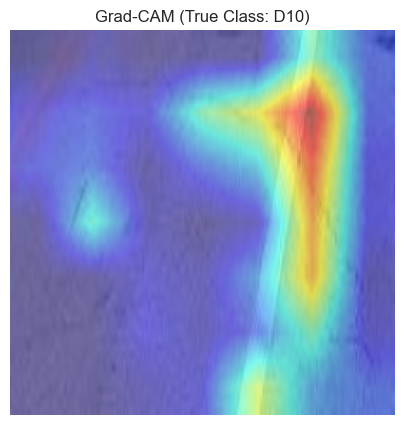

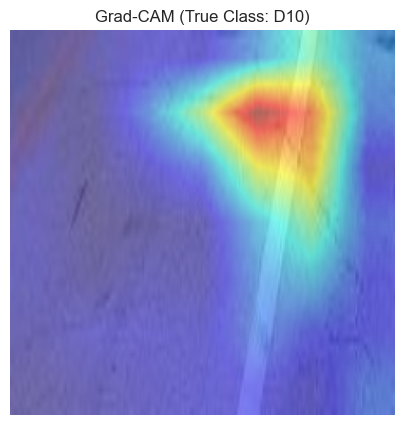

In [6]:
print("Generating Grad-CAM visualizations...")
# Get a single batch to visualize
images, labels = next(iter(test_loader))
sample_img, sample_label = images[2], labels[2].item()

# Un-normalize image for visualization
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
visual_img = inv_normalize(sample_img).permute(1, 2, 0).numpy()
visual_img = np.clip(visual_img * 255, 0, 255).astype(np.uint8)

# Target the final convolutional layers for both models
generate_gradcam(resnet_model, [resnet_model.layer4[-1]], sample_img.to(device), visual_img, sample_label)
generate_gradcam(effnet_model, [effnet_model.features[-1]], sample_img.to(device), visual_img, sample_label)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4481792..1.8267832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3850982..1.073294].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5071026..1.2959158].


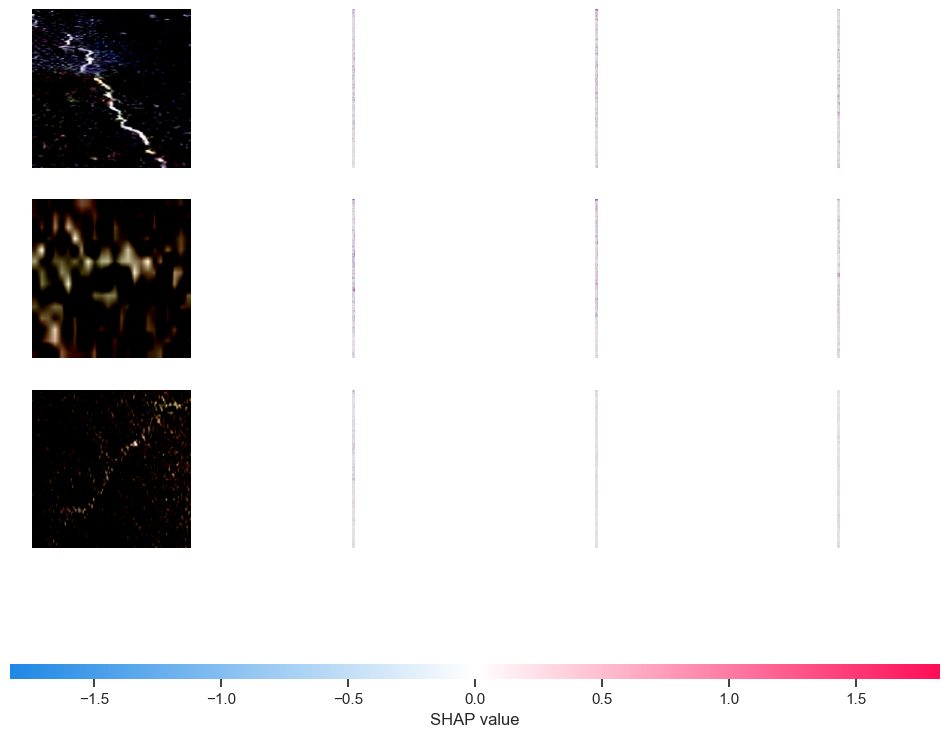

In [8]:
explainer = shap.GradientExplainer(effnet_model, background)
shap_values = explainer.shap_values(test_images)

# Plot SHAP values (convert tensors to numpy channels-last format for SHAP)
shap_numpy = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_values]
test_numpy = np.swapaxes(np.swapaxes(test_images.cpu().numpy(), 1, -1), 1, 2)

shap.image_plot(shap_numpy, -test_numpy)

In [10]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Generate the raw NumPy array
cm_resnet = confusion_matrix(y_true, y_pred_res)
cm_effnet = confusion_matrix(y_true, y_pred_eff)

print("--- ResNet50 Raw Confusion Matrix ---")
print(cm_resnet)

print("\n--- EfficientNet-B0 Raw Confusion Matrix ---")
print(cm_effnet)
# 2. Make it readable in the console using a Pandas DataFrame
target_names = ['D00 (Longitudinal)', 'D10 (Transverse)', 'D20 (Alligator)', 'D40 (Pothole)']

df_cm_resnet = pd.DataFrame(cm_resnet, index=target_names, columns=target_names)
df_cm_effnet = pd.DataFrame(cm_effnet, index=target_names, columns=target_names)

print("\n--- ResNet50 Labeled Matrix ---")
print(df_cm_resnet)

print("\n--- EfficientNet-B0 Labeled Matrix ---")
print(df_cm_effnet)

--- ResNet50 Raw Confusion Matrix ---
[[5090   73  128   81]
 [ 106 2205   15   24]
 [ 167   25 1890   65]
 [  46    7   25 1293]]

--- EfficientNet-B0 Raw Confusion Matrix ---
[[4974  126  188   84]
 [  75 2254    8   13]
 [ 100   26 1977   44]
 [  25   14   45 1287]]

--- ResNet50 Labeled Matrix ---
                    D00 (Longitudinal)  D10 (Transverse)  D20 (Alligator)  \
D00 (Longitudinal)                5090                73              128   
D10 (Transverse)                   106              2205               15   
D20 (Alligator)                    167                25             1890   
D40 (Pothole)                       46                 7               25   

                    D40 (Pothole)  
D00 (Longitudinal)             81  
D10 (Transverse)               24  
D20 (Alligator)                65  
D40 (Pothole)                1293  

--- EfficientNet-B0 Labeled Matrix ---
                    D00 (Longitudinal)  D10 (Transverse)  D20 (Alligator)  \
D00 (Longitudi

In [11]:
resnet_model.summary(input_size=(3, 224, 224))

AttributeError: 'ResNet' object has no attribute 'summary'

In [12]:
# Print ResNet50 architecture
print(resnet_model)

# Print EfficientNet-B0 architecture
print(effnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 